In [2]:
# ==========================================
# BEFORE TRAINING – BASE MODEL EVALUATION
# ==========================================
import os
import time
import json
import torch
import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ==========================================
# DEVICE SETUP (CUDA → CPU FALLBACK)
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("🛡️ Using CPU")

# ==========================================
# CONFIG
# ==========================================
base_model_id = "facebook/nllb-200-distilled-600M"
test_file = "translation_test_pairs_50.json"

SRC_KEY = "tamil"
TGT_KEY = "english"
SRC_LANG = "tam_Taml"
TGT_LANG = "eng_Latn"

# ==========================================
# LOAD MODEL
# ==========================================
print("⏳ Loading model...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id).to(device)
model.eval()

bleu = evaluate.load("sacrebleu")
chrf = evaluate.load("chrf")

# ==========================================
# LOAD & NORMALIZE DATA
# ==========================================
with open(test_file, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# 🔧 HANDLE MULTIPLE JSON FORMATS
if isinstance(raw_data, dict) and "pairs" in raw_data:
    data = raw_data["pairs"]
elif isinstance(raw_data, list):
    data = raw_data
else:
    raise ValueError("❌ Unsupported JSON structure")

print(f"✅ Loaded {len(data)} test samples")

# ==========================================
# EVALUATION LOOP
# ==========================================
predictions = []
references = []
total_time = 0.0
valid_count = 0

for i, row in enumerate(data):
    # 🛡️ SAFETY CHECK
    if not isinstance(row, dict):
        print(f"⚠️ Skipping row {i}: not a dict")
        continue

    if SRC_KEY not in row or TGT_KEY not in row:
        print(f"⚠️ Skipping row {i}: missing keys {row.keys()}")
        continue

    src_text = row[SRC_KEY]
    tgt_text = row[TGT_KEY]

    tokenizer.src_lang = SRC_LANG
    inputs = tokenizer(
        src_text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    # ⏱ Accurate timing (GPU-safe)
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(TGT_LANG),
            max_length=128,
            num_beams=4
        )

    if device == "cuda":
        torch.cuda.synchronize()
    end = time.time()

    total_time += (end - start)

    pred = tokenizer.decode(output[0], skip_special_tokens=True)
    predictions.append(pred)
    references.append([tgt_text])
    valid_count += 1

    if i % 10 == 0:
        print(f"   Processed {i}/{len(data)}")

# ==========================================
# METRICS
# ==========================================
if valid_count == 0:
    raise RuntimeError("❌ No valid samples to evaluate")

bleu_score = bleu.compute(
    predictions=predictions,
    references=references
)["score"]

chrf_score = chrf.compute(
    predictions=predictions,
    references=references
)["score"]

avg_latency = total_time / valid_count

print("\n===== BEFORE TRAINING RESULTS =====")
print(f"Samples Evaluated : {valid_count}")
print(f"BLEU              : {bleu_score:.2f}")
print(f"CHRF++            : {chrf_score:.2f}")
print(f"Avg Latency (sec) : {avg_latency:.3f}")
print("==================================")


🚀 Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
⏳ Loading model...
✅ Loaded 60 test samples
   Processed 0/60
   Processed 10/60
   Processed 20/60
   Processed 30/60
   Processed 40/60
   Processed 50/60

===== BEFORE TRAINING RESULTS =====
Samples Evaluated : 60
BLEU              : 30.23
CHRF++            : 52.90
Avg Latency (sec) : 2.707


In [3]:
# ==========================================
# ENGLISH → TAMIL EVALUATION
# ==========================================
SRC_KEY_REV = "english"
TGT_KEY_REV = "tamil"
SRC_LANG_REV = "eng_Latn"
TGT_LANG_REV = "tam_Taml"

print("\n🔁 Evaluating English → Tamil")

predictions_rev = []
references_rev = []
total_time_rev = 0.0
valid_count_rev = 0

for i, row in enumerate(data):
    # Safety checks
    if not isinstance(row, dict):
        continue
    if SRC_KEY_REV not in row or TGT_KEY_REV not in row:
        continue

    src_text = row[SRC_KEY_REV]
    tgt_text = row[TGT_KEY_REV]

    tokenizer.src_lang = SRC_LANG_REV
    inputs = tokenizer(
        src_text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    # Accurate timing
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(TGT_LANG_REV),
            max_length=128,
            num_beams=4
        )

    if device == "cuda":
        torch.cuda.synchronize()
    end = time.time()

    total_time_rev += (end - start)

    pred = tokenizer.decode(output[0], skip_special_tokens=True)
    predictions_rev.append(pred)
    references_rev.append([tgt_text])
    valid_count_rev += 1
bleu_score_rev = bleu.compute(
    predictions=predictions_rev,
    references=references_rev
)["score"]

chrf_score_rev = chrf.compute(
    predictions=predictions_rev,
    references=references_rev
)["score"]

avg_latency_rev = total_time_rev / valid_count_rev

print("\n===== ENGLISH → TAMIL RESULTS =====")
print(f"Samples Evaluated : {valid_count_rev}")
print(f"BLEU              : {bleu_score_rev:.2f}")
print(f"CHRF++            : {chrf_score_rev:.2f}")
print(f"Avg Latency (sec) : {avg_latency_rev:.3f}")
print("==================================")



🔁 Evaluating English → Tamil

===== ENGLISH → TAMIL RESULTS =====
Samples Evaluated : 60
BLEU              : 23.65
CHRF++            : 61.13
Avg Latency (sec) : 3.271


1. EVALUATION: facebook/m2m100_418M for Tamil

In [1]:
import time
import json
import torch
import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel

# ==========================================
# 1. SETUP & HELPER FUNCTIONS
# ==========================================
def get_device():
    """Automatically selects CUDA or CPU."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cuda":
        print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("🛡️ Using CPU")
    return device

def load_test_data(test_file):
    """Loads and normalizes the JSON test data."""
    with open(test_file, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    
    if isinstance(raw_data, dict) and "pairs" in raw_data:
        return raw_data["pairs"]
    elif isinstance(raw_data, list):
        return raw_data
    else:
        raise ValueError("❌ Unsupported JSON structure")

# ==========================================
# 2. CORE EVALUATION FUNCTION
# ==========================================
def evaluate_bidirectional(
    base_model_id, 
    test_file="translation_test_pairs_50.json",
    adapter_path=None,
    src_lang_code="ta", # Default M2M100 code for Tamil
    tgt_lang_code="en"  # Default M2M100 code for English
):
    """
    Loads a model (optional LoRA) and evaluates it in both directions.
    
    Args:
        base_model_id (str): HuggingFace model ID (e.g., "facebook/m2m100_418M").
        test_file (str): Path to JSON test file.
        adapter_path (str or None): Path to LoRA adapter. If None, uses base model.
        src_lang_code (str): Language code for Source (e.g., 'ta' for M2M, 'tam_Taml' for NLLB).
        tgt_lang_code (str): Language code for Target (e.g., 'en' for M2M, 'eng_Latn' for NLLB).
    """
    device = get_device()
    
    print(f"\n**************************************************")
    print(f"🧪 STARTING EVALUATION: {base_model_id}")
    if adapter_path:
        print(f"🔗 Adapter: {adapter_path}")
    print(f"**************************************************")

    # --- Load Model & Tokenizer ---
    print("⏳ Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(base_model_id)
    base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id)

    if adapter_path:
        print("Settings: Loading LoRA Adapter...")
        model = PeftModel.from_pretrained(base_model, adapter_path)
    else:
        print("Settings: Standard Base Model (No Adapter)")
        model = base_model

    model = model.to(device)
    model.eval()

    # --- Load Metrics & Data ---
    bleu = evaluate.load("sacrebleu")
    chrf = evaluate.load("chrf")
    data = load_test_data(test_file)
    print(f"✅ Loaded {len(data)} test samples")

    # --- Define Inner Evaluation Loop (To avoid code duplication) ---
    def run_eval_direction(direction_name, source_key, target_key, s_lang, t_lang):
        print(f"\n==============================")
        print(f"🔁 EVALUATION: {direction_name}")
        print(f"==============================")

        predictions = []
        references = []
        total_time = 0.0
        valid_count = 0

        for row in data:
            if source_key not in row or target_key not in row:
                continue

            # Set Source Language
            tokenizer.src_lang = s_lang
            
            inputs = tokenizer(
                row[source_key],
                return_tensors="pt",
                truncation=True,
                max_length=128
            ).to(device)

            if device == "cuda": torch.cuda.synchronize()
            start = time.time()

            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    forced_bos_token_id=tokenizer.get_lang_id(t_lang), # Critical for M2M100
                    max_length=128,
                    num_beams=4,
                    use_cache=True
                )

            if device == "cuda": torch.cuda.synchronize()
            end = time.time()
            total_time += (end - start)

            pred = tokenizer.decode(output[0], skip_special_tokens=True)
            predictions.append(pred)
            references.append([row[target_key]])
            valid_count += 1

        # Calculate Metrics
        b_score = bleu.compute(predictions=predictions, references=references)["score"]
        c_score = chrf.compute(predictions=predictions, references=references)["score"]
        latency = total_time / valid_count if valid_count > 0 else 0

        print(f"Samples Evaluated : {valid_count}")
        print(f"BLEU              : {b_score:.2f}")
        print(f"CHRF++            : {c_score:.2f}")
        print(f"Avg Latency (sec) : {latency:.3f}")
        
        return b_score, c_score

    # --- Run Both Directions ---
    # 1. Tamil -> English
    bleu_te, chrf_te = run_eval_direction(
        "Tamil -> English", "tamil", "english", src_lang_code, tgt_lang_code
    )

    # 2. English -> Tamil
    bleu_et, chrf_et = run_eval_direction(
        "English -> Tamil", "english", "tamil", tgt_lang_code, src_lang_code
    )

    # --- Final Summary ---
    print("\n==============================")
    print(f"🏁 FINAL SUMMARY: {base_model_id}")
    print("==============================")
    print(f"Tam → Eng | BLEU: {bleu_te:.2f} | CHRF++: {chrf_te:.2f}")
    print(f"Eng → Tam | BLEU: {bleu_et:.2f} | CHRF++: {chrf_et:.2f}")
    print("==============================\n")

# ==========================================
# 3. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    
    # TEST 1: M2M100 Base Model (No Adapter)
    # Note: M2M100 uses 'ta' and 'en' language codes
    evaluate_bidirectional(
        base_model_id="facebook/m2m100_418M",
        test_file="translation_test_pairs_50.json",
        adapter_path=None,  # Set to path if you have a LoRA for M2M
        src_lang_code="ta",
        tgt_lang_code="en"
    )

    # TEST 2: (Commented out) Example for NLLB
    # If you want to test your previous NLLB model, you would call it like this:
    # evaluate_bidirectional(
    #     base_model_id="facebook/nllb-200-distilled-600M",
    #     adapter_path="./nllb-legal-final",
    #     src_lang_code="tam_Taml",
    #     tgt_lang_code="eng_Latn"
    # )

d:\reserach-testing\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU

**************************************************
🧪 STARTING EVALUATION: facebook/m2m100_418M
**************************************************
⏳ Loading model...
Settings: Standard Base Model (No Adapter)


✅ Loaded 60 test samples

🔁 EVALUATION: Tamil -> English
Samples Evaluated : 60
BLEU              : 6.73
CHRF++            : 26.56
Avg Latency (sec) : 0.312

🔁 EVALUATION: English -> Tamil
Samples Evaluated : 60
BLEU              : 6.74
CHRF++            : 34.37
Avg Latency (sec) : 0.470

🏁 FINAL SUMMARY: facebook/m2m100_418M
Tam → Eng | BLEU: 6.73 | CHRF++: 26.56
Eng → Tam | BLEU: 6.74 | CHRF++: 34.37



1.1  EVALUATION: facebook/m2m100_418M for Sinhala

In [4]:
import os
import time
import json
import torch
import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ==========================================
# 1. SETUP
# ==========================================
# Path to your JSON file
TEST_FILE_PATH = r"D:\reserach-testing\sinhala_testing_tranlation pair.json"

# Model ID (You selected M2M100)
MODEL_ID = "facebook/m2m100_418M"

def get_device():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"🚀 Using Device: {device}")
    return device

def load_test_data(test_file):
    if not os.path.exists(test_file):
        raise FileNotFoundError(f"❌ Test file '{test_file}' not found.")
        
    with open(test_file, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    
    # Handle list or dict format
    if isinstance(raw_data, dict) and "pairs" in raw_data:
        return raw_data["pairs"]
    elif isinstance(raw_data, list):
        return raw_data
    else:
        return []

# ==========================================
# 2. EVALUATION LOGIC
# ==========================================
def evaluate_model():
    device = get_device()
    
    # Load Model & Tokenizer
    print(f"⏳ Loading model: {MODEL_ID} ...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID).to(device)
    model.eval()

    # Load Metrics
    try:
        bleu = evaluate.load("sacrebleu")
        chrf = evaluate.load("chrf")
    except Exception as e:
        print("⚠️ Error loading metrics. Run: pip install evaluate sacrebleu chrf")
        raise e

    # Load Data
    data = load_test_data(TEST_FILE_PATH)
    print(f"✅ Loaded {len(data)} test samples")

    # Define JSON keys (Ensure these match your JSON file)
    KEY_SIN = "sinhala"
    KEY_ENG = "english"

    # --- Internal Function to Run One Direction ---
    def run_direction(src_code, tgt_code, src_key, tgt_key):
        print(f"\n==============================")
        print(f"🔁 EVALUATION: {src_code} -> {tgt_code}")
        print(f"==============================")

        predictions = []
        references = []
        total_time = 0.0
        valid_count = 0

        for row in data:
            if src_key not in row or tgt_key not in row:
                continue

            text_input = row[src_key]
            text_ref = row[tgt_key]

            # 1. Set Source Language (Required for M2M100)
            tokenizer.src_lang = src_code

            # 2. Tokenize
            inputs = tokenizer(text_input, return_tensors="pt", truncation=True, max_length=128).to(device)

            # 3. Generate
            if device == "cuda": torch.cuda.synchronize()
            start = time.time()
            
            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    # M2M100 specific: use get_lang_id
                    forced_bos_token_id=tokenizer.get_lang_id(tgt_code),
                    max_length=128,
                    num_beams=4
                )
            
            if device == "cuda": torch.cuda.synchronize()
            end = time.time()
            total_time += (end - start)

            # 4. Decode
            pred = tokenizer.decode(output[0], skip_special_tokens=True)
            predictions.append(pred)
            references.append([text_ref])
            valid_count += 1
            
            # Progress indicator
            if valid_count % 20 == 0:
                print(f"   ...Processed {valid_count} samples")

        # Compute Metrics
        if valid_count > 0:
            b_score = bleu.compute(predictions=predictions, references=references)["score"]
            c_score = chrf.compute(predictions=predictions, references=references)["score"]
            latency = total_time / valid_count
        else:
            b_score, c_score, latency = 0, 0, 0

        print(f"Samples Evaluated : {valid_count}")
        print(f"BLEU              : {b_score:.2f}")
        print(f"CHRF++            : {c_score:.2f}")
        print(f"Avg Latency (sec) : {latency:.3f}")
        
        return b_score, c_score

    # ==========================================
    # 3. RUN TESTS
    # ==========================================
    
    # NOTE: M2M100 uses "si" for Sinhala and "en" for English
    
    # 1. Sinhala -> English
    b_se, c_se = run_direction("si", "en", KEY_SIN, KEY_ENG)

    # 2. English -> Sinhala
    b_es, c_es = run_direction("en", "si", KEY_ENG, KEY_SIN)

    # ==========================================
    # 4. FINAL SUMMARY
    # ==========================================
    print("\n==============================")
    print(f"🏁 FINAL SUMMARY: {MODEL_ID}")
    print("==============================")
    print(f"Sin → Eng | BLEU: {b_se:.2f} | CHRF++: {c_se:.2f}")
    print(f"Eng → Sin | BLEU: {b_es:.2f} | CHRF++: {c_es:.2f}")
    print("==============================\n")

if __name__ == "__main__":
    evaluate_model()

🚀 Using Device: cuda
⏳ Loading model: facebook/m2m100_418M ...
✅ Loaded 60 test samples

🔁 EVALUATION: si -> en
   ...Processed 20 samples
   ...Processed 40 samples
   ...Processed 60 samples
Samples Evaluated : 60
BLEU              : 20.08
CHRF++            : 46.04
Avg Latency (sec) : 2.614

🔁 EVALUATION: en -> si
   ...Processed 20 samples
   ...Processed 40 samples
   ...Processed 60 samples
Samples Evaluated : 60
BLEU              : 13.33
CHRF++            : 37.46
Avg Latency (sec) : 6.658

🏁 FINAL SUMMARY: facebook/m2m100_418M
Sin → Eng | BLEU: 20.08 | CHRF++: 46.04
Eng → Sin | BLEU: 13.33 | CHRF++: 37.46



2.  EVALUATION: facebook/nllb-200-distilled-600M for tamil


In [2]:
import os
import time
import json
import torch
import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel

# ==========================================
# 1. SETUP & HELPER FUNCTIONS
# ==========================================
def get_device():
    """Automatically selects CUDA or CPU."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cuda":
        print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("🛡️ Using CPU")
    return device

def load_test_data(test_file):
    """Loads and normalizes the JSON test data."""
    if not os.path.exists(test_file):
        raise FileNotFoundError(f"❌ Test file '{test_file}' not found.")
        
    with open(test_file, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    
    if isinstance(raw_data, dict) and "pairs" in raw_data:
        return raw_data["pairs"]
    elif isinstance(raw_data, list):
        return raw_data
    else:
        raise ValueError("❌ Unsupported JSON structure")

# ==========================================
# 2. CORE EVALUATION FUNCTION
# ==========================================
def evaluate_bidirectional(
    base_model_id="facebook/nllb-200-distilled-600M", 
    test_file="translation_test_pairs_50.json",
    adapter_path=None,
    src_lang_code="tam_Taml", # Correct NLLB code for Tamil
    tgt_lang_code="eng_Latn"  # Correct NLLB code for English
):
    """
    Evaluates NLLB model in both directions (Tamil <-> English).
    """
    device = get_device()
    
    print(f"\n**************************************************")
    print(f"🧪 STARTING EVALUATION: {base_model_id}")
    if adapter_path:
        print(f"🔗 Adapter: {adapter_path}")
    else:
        print(f"🔗 Mode: Base Model Only")
    print(f"**************************************************")

    # --- Load Model & Tokenizer ---
    print("⏳ Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(base_model_id)
    base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id)

    if adapter_path:
        print("Settings: Loading LoRA Adapter...")
        model = PeftModel.from_pretrained(base_model, adapter_path)
    else:
        print("Settings: Standard Base Model")
        model = base_model

    model = model.to(device)
    model.eval()

    # --- Load Metrics & Data ---
    bleu = evaluate.load("sacrebleu")
    chrf = evaluate.load("chrf")
    data = load_test_data(test_file)
    print(f"✅ Loaded {len(data)} test samples")

    # --- Inner Evaluation Loop ---
    def run_eval_direction(direction_name, source_key, target_key, s_lang, t_lang):
        print(f"\n==============================")
        print(f"🔁 EVALUATION: {direction_name}")
        print(f"==============================")

        predictions = []
        references = []
        total_time = 0.0
        valid_count = 0

        for row in data:
            if source_key not in row or target_key not in row:
                continue

            # Set Source Language (Crucial for NLLB)
            tokenizer.src_lang = s_lang
            
            inputs = tokenizer(
                row[source_key],
                return_tensors="pt",
                truncation=True,
                max_length=128
            ).to(device)

            if device == "cuda": torch.cuda.synchronize()
            start = time.time()

            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    forced_bos_token_id=tokenizer.convert_tokens_to_ids(t_lang), # Correct NLLB method
                    max_length=128,
                    num_beams=4,
                    use_cache=True
                )

            if device == "cuda": torch.cuda.synchronize()
            end = time.time()
            total_time += (end - start)

            pred = tokenizer.decode(output[0], skip_special_tokens=True)
            predictions.append(pred)
            references.append([row[target_key]])
            valid_count += 1
            
            if valid_count % 10 == 0:
                print(f"   Processed {valid_count} samples...")

        # Calculate Metrics
        if valid_count == 0:
            print("❌ No valid samples found.")
            return 0.0, 0.0

        b_score = bleu.compute(predictions=predictions, references=references)["score"]
        c_score = chrf.compute(predictions=predictions, references=references)["score"]
        latency = total_time / valid_count

        print(f"Samples Evaluated : {valid_count}")
        print(f"BLEU              : {b_score:.2f}")
        print(f"CHRF++            : {c_score:.2f}")
        print(f"Avg Latency (sec) : {latency:.3f}")
        
        return b_score, c_score

    # --- Run Both Directions ---
    
    # 1. Tamil -> English
    bleu_te, chrf_te = run_eval_direction(
        "Tamil -> English", "tamil", "english", src_lang_code, tgt_lang_code
    )

    # 2. English -> Tamil
    bleu_et, chrf_et = run_eval_direction(
        "English -> Tamil", "english", "tamil", tgt_lang_code, src_lang_code
    )

    # --- Final Summary ---
    print("\n==============================")
    print(f"🏁 FINAL SUMMARY: {base_model_id}")
    print("==============================")
    print(f"Tam → Eng | BLEU: {bleu_te:.2f} | CHRF++: {chrf_te:.2f}")
    print(f"Eng → Tam | BLEU: {bleu_et:.2f} | CHRF++: {chrf_et:.2f}")
    print("==============================\n")

# ==========================================
# 3. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    
    # Evaluate Base NLLB-200-600M
    evaluate_bidirectional(
        base_model_id="facebook/nllb-200-distilled-600M",
        test_file="translation_test_pairs_50.json",
        adapter_path=None,  # Set this to a path (e.g., "./nllb-finetuned") if you want to test a trained model
        src_lang_code="tam_Taml",
        tgt_lang_code="eng_Latn"
    )

🚀 Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU

**************************************************
🧪 STARTING EVALUATION: facebook/nllb-200-distilled-600M
🔗 Mode: Base Model Only
**************************************************
⏳ Loading model...
Settings: Standard Base Model
✅ Loaded 60 test samples

🔁 EVALUATION: Tamil -> English
   Processed 10 samples...
   Processed 20 samples...
   Processed 30 samples...
   Processed 40 samples...
   Processed 50 samples...
   Processed 60 samples...
Samples Evaluated : 60
BLEU              : 30.23
CHRF++            : 52.90
Avg Latency (sec) : 2.396

🔁 EVALUATION: English -> Tamil
   Processed 10 samples...
   Processed 20 samples...
   Processed 30 samples...
   Processed 40 samples...
   Processed 50 samples...
   Processed 60 samples...
Samples Evaluated : 60
BLEU              : 23.65
CHRF++            : 61.13
Avg Latency (sec) : 2.904

🏁 FINAL SUMMARY: facebook/nllb-200-distilled-600M
Tam → Eng | BLEU: 30.23 | CHRF++: 52.90
Eng → Tam |

2.1  EVALUATION: facebook/nllb-200-distilled-600M for tamil

In [2]:
import os
import time
import json
import torch
import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ==========================================
# 1. SETUP
# ==========================================
TEST_FILE_PATH = r"D:\reserach-testing\sinhala_testing_tranlation pair.json"
MODEL_ID = "facebook/nllb-200-distilled-600M"

def get_device():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"🚀 Using Device: {device}")
    return device

def load_test_data(test_file):
    if not os.path.exists(test_file):
        raise FileNotFoundError(f"❌ Test file '{test_file}' not found.")
        
    with open(test_file, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    
    # Handle list or dict format
    if isinstance(raw_data, dict) and "pairs" in raw_data:
        return raw_data["pairs"]
    elif isinstance(raw_data, list):
        return raw_data
    else:
        return []

# ==========================================
# 2. EVALUATION LOGIC
# ==========================================
def evaluate_model():
    device = get_device()
    
    # Load Model & Tokenizer
    print("⏳ Loading model and metrics...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID).to(device)
    model.eval()

    # Load Metrics
    try:
        bleu = evaluate.load("sacrebleu")
        chrf = evaluate.load("chrf")
    except Exception as e:
        print("⚠️ Error loading metrics. Make sure to install: pip install evaluate sacrebleu chrf")
        raise e

    # Load Data
    data = load_test_data(TEST_FILE_PATH)
    print(f"✅ Loaded {len(data)} test samples")

    # Define JSON keys (Change these if your JSON uses 'si'/'en')
    KEY_SIN = "sinhala"
    KEY_ENG = "english"

    # --- Internal Function to Run One Direction ---
    def run_direction(src_code, tgt_code, src_key, tgt_key):
        print(f"\n==============================")
        print(f"🔁 EVALUATION: {src_code} -> {tgt_code}")
        print(f"==============================")

        predictions = []
        references = []
        total_time = 0.0
        valid_count = 0

        # forced_bos_token_id is crucial for NLLB
        target_lang_id = tokenizer.convert_tokens_to_ids(tgt_code)

        for row in data:
            if src_key not in row or tgt_key not in row:
                continue

            text_input = row[src_key]
            text_ref = row[tgt_key]

            # Tokenize
            tokenizer.src_lang = src_code
            inputs = tokenizer(text_input, return_tensors="pt", truncation=True, max_length=128).to(device)

            # Generate
            if device == "cuda": torch.cuda.synchronize()
            start = time.time()
            
            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    forced_bos_token_id=target_lang_id,
                    max_length=128,
                    num_beams=4
                )
            
            if device == "cuda": torch.cuda.synchronize()
            end = time.time()
            total_time += (end - start)

            # Decode
            pred = tokenizer.decode(output[0], skip_special_tokens=True)
            predictions.append(pred)
            references.append([text_ref])
            valid_count += 1
            
            # Optional: Progress indicator
            if valid_count % 20 == 0:
                print(f"   ...Processed {valid_count} samples")

        # Compute Metrics
        if valid_count > 0:
            b_score = bleu.compute(predictions=predictions, references=references)["score"]
            c_score = chrf.compute(predictions=predictions, references=references)["score"]
            latency = total_time / valid_count
        else:
            b_score, c_score, latency = 0, 0, 0

        print(f"Samples Evaluated : {valid_count}")
        print(f"BLEU              : {b_score:.2f}")
        print(f"CHRF++            : {c_score:.2f}")
        print(f"Avg Latency (sec) : {latency:.3f}")
        
        return b_score, c_score

    # ==========================================
    # 3. RUN TESTS
    # ==========================================
    
    # 1. Sinhala -> English (sin_Sinh -> eng_Latn)
    b_se, c_se = run_direction("sin_Sinh", "eng_Latn", KEY_SIN, KEY_ENG)

    # 2. English -> Sinhala (eng_Latn -> sin_Sinh)
    b_es, c_es = run_direction("eng_Latn", "sin_Sinh", KEY_ENG, KEY_SIN)

    # ==========================================
    # 4. FINAL SUMMARY
    # ==========================================
    print("\n==============================")
    print(f"🏁 FINAL SUMMARY")
    print("==============================")
    print(f"Sin → Eng | BLEU: {b_se:.2f} | CHRF++: {c_se:.2f}")
    print(f"Eng → Sin | BLEU: {b_es:.2f} | CHRF++: {c_es:.2f}")
    print("==============================\n")

if __name__ == "__main__":
    evaluate_model()

🚀 Using Device: cuda
⏳ Loading model and metrics...
✅ Loaded 60 test samples

🔁 EVALUATION: sin_Sinh -> eng_Latn
   ...Processed 20 samples
   ...Processed 40 samples
   ...Processed 60 samples
Samples Evaluated : 60
BLEU              : 32.69
CHRF++            : 56.60
Avg Latency (sec) : 2.515

🔁 EVALUATION: eng_Latn -> sin_Sinh
   ...Processed 20 samples
   ...Processed 40 samples
   ...Processed 60 samples
Samples Evaluated : 60
BLEU              : 21.44
CHRF++            : 54.00
Avg Latency (sec) : 3.331

🏁 FINAL SUMMARY
Sin → Eng | BLEU: 32.69 | CHRF++: 56.60
Eng → Sin | BLEU: 21.44 | CHRF++: 54.00



3. EVALUATION: facebook/nllb-200-1.3B for tamil

In [3]:
import time
import json
import torch
import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel

# ==========================================
# 1. SETUP & HELPER FUNCTIONS
# ==========================================
def get_device():
    """Automatically selects CUDA or CPU."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cuda":
        print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("🛡️ Using CPU")
    return device

def load_test_data(test_file):
    """Loads and normalizes the JSON test data."""
    with open(test_file, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    
    if isinstance(raw_data, dict) and "pairs" in raw_data:
        return raw_data["pairs"]
    elif isinstance(raw_data, list):
        return raw_data
    else:
        raise ValueError("❌ Unsupported JSON structure")

# ==========================================
# 2. CORE EVALUATION FUNCTION
# ==========================================
def evaluate_bidirectional(
    base_model_id, 
    test_file="translation_test_pairs_50.json",
    adapter_path=None,
    src_lang_code="tam_Taml", # Default to NLLB code
    tgt_lang_code="eng_Latn"  # Default to NLLB code
):
    """
    Evaluates NLLB or M2M models.
    NOTE: NLLB requires specific codes like 'tam_Taml' (not 'ta') and 'eng_Latn' (not 'en').
    """
    device = get_device()
    
    print(f"\n**************************************************")
    print(f"🧪 STARTING EVALUATION: {base_model_id}")
    print(f"🌍 Source Code: {src_lang_code} | Target Code: {tgt_lang_code}")
    if adapter_path:
        print(f"🔗 Adapter: {adapter_path}")
    print(f"**************************************************")

    # --- Load Model & Tokenizer ---
    print("⏳ Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(base_model_id)
    base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id)

    if adapter_path:
        print("Settings: Loading LoRA Adapter...")
        model = PeftModel.from_pretrained(base_model, adapter_path)
    else:
        print("Settings: Standard Base Model (No Adapter)")
        model = base_model

    model = model.to(device)
    model.eval()

    # --- Load Metrics & Data ---
    bleu = evaluate.load("sacrebleu")
    chrf = evaluate.load("chrf")
    data = load_test_data(test_file)
    print(f"✅ Loaded {len(data)} test samples")

    # --- Inner Loop Function ---
    def run_eval_direction(direction_name, source_key, target_key, s_lang, t_lang):
        print(f"\n==============================")
        print(f"🔁 EVALUATION: {direction_name}")
        print(f"==============================")

        predictions = []
        references = []
        total_time = 0.0
        valid_count = 0

        # Pre-calculate target token ID for forced BOS
        # NLLB usually relies on convert_tokens_to_ids for the language code
        forced_bos_id = tokenizer.convert_tokens_to_ids(t_lang)

        for row in data:
            if source_key not in row or target_key not in row:
                continue

            # IMPORTANT: NLLB needs src_lang set on the tokenizer
            tokenizer.src_lang = s_lang
            
            inputs = tokenizer(
                row[source_key],
                return_tensors="pt",
                truncation=True,
                max_length=128
            ).to(device)

            if device == "cuda": torch.cuda.synchronize()
            start = time.time()

            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    forced_bos_token_id=forced_bos_id, 
                    max_length=128,
                    num_beams=4,
                    use_cache=True
                )

            if device == "cuda": torch.cuda.synchronize()
            end = time.time()
            total_time += (end - start)

            pred = tokenizer.decode(output[0], skip_special_tokens=True)
            predictions.append(pred)
            references.append([row[target_key]])
            valid_count += 1

        b_score = bleu.compute(predictions=predictions, references=references)["score"]
        c_score = chrf.compute(predictions=predictions, references=references)["score"]
        latency = total_time / valid_count if valid_count > 0 else 0

        print(f"Samples Evaluated : {valid_count}")
        print(f"BLEU              : {b_score:.2f}")
        print(f"CHRF++            : {c_score:.2f}")
        print(f"Avg Latency (sec) : {latency:.3f}")
        
        return b_score, c_score

    # --- Run Both Directions ---
    # 1. Source (Tamil) -> Target (English)
    bleu_te, chrf_te = run_eval_direction(
        f"{src_lang_code} -> {tgt_lang_code}", "tamil", "english", src_lang_code, tgt_lang_code
    )

    # 2. Target (English) -> Source (Tamil)
    bleu_et, chrf_et = run_eval_direction(
        f"{tgt_lang_code} -> {src_lang_code}", "english", "tamil", tgt_lang_code, src_lang_code
    )

    # --- Final Summary ---
    print("\n==============================")
    print(f"🏁 FINAL SUMMARY: {base_model_id}")
    print("==============================")
    print(f"Tam → Eng | BLEU: {bleu_te:.2f} | CHRF++: {chrf_te:.2f}")
    print(f"Eng → Tam | BLEU: {bleu_et:.2f} | CHRF++: {chrf_et:.2f}")
    print("==============================\n")

# ==========================================
# 3. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    
    # Running for NLLB 1.3B
    evaluate_bidirectional(
        base_model_id="facebook/nllb-200-1.3B",
        test_file="translation_test_pairs_50.json",
        adapter_path=None, 
        
        # ⚠️ CRITICAL: Use NLLB Specific Language Codes
        src_lang_code="tam_Taml", 
        tgt_lang_code="eng_Latn"
    )

🚀 Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU

**************************************************
🧪 STARTING EVALUATION: facebook/nllb-200-1.3B
🌍 Source Code: tam_Taml | Target Code: eng_Latn
**************************************************
⏳ Loading model...
Settings: Standard Base Model (No Adapter)
✅ Loaded 60 test samples

🔁 EVALUATION: tam_Taml -> eng_Latn
Samples Evaluated : 60
BLEU              : 26.86
CHRF++            : 51.33
Avg Latency (sec) : 18.728

🔁 EVALUATION: eng_Latn -> tam_Taml
Samples Evaluated : 60
BLEU              : 24.16
CHRF++            : 64.04
Avg Latency (sec) : 16.962

🏁 FINAL SUMMARY: facebook/nllb-200-1.3B
Tam → Eng | BLEU: 26.86 | CHRF++: 51.33
Eng → Tam | BLEU: 24.16 | CHRF++: 64.04



In [7]:
import os
import time
import json
import torch
import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ==========================================
# 1. SETUP
# ==========================================
TEST_FILE_PATH = r"D:\reserach-testing\sinhala_testing_tranlation pair.json"
MODEL_ID = "facebook/nllb-200-1.3B"

def load_test_data(test_file):
    if not os.path.exists(test_file):
        raise FileNotFoundError(f"❌ Test file '{test_file}' not found.")
        
    with open(test_file, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    
    if isinstance(raw_data, dict) and "pairs" in raw_data:
        return raw_data["pairs"]
    elif isinstance(raw_data, list):
        return raw_data
    else:
        return []

# ==========================================
# 2. EVALUATION LOGIC
# ==========================================
def evaluate_model():
    # 1. Force CPU Device
    device = "cpu"
    print(f"🛡️ Using Device: {device} (Slow but stable)")

    # 2. Load Model & Tokenizer
    print(f"⏳ Loading model: {MODEL_ID}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    
    # Load model directly to CPU (No 8-bit, no device_map)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID).to(device)
    model.eval()

    # 3. Load Metrics
    try:
        bleu = evaluate.load("sacrebleu")
        chrf = evaluate.load("chrf")
    except Exception as e:
        print("⚠️ Error loading metrics. Run: pip install evaluate sacrebleu chrf")
        raise e

    # 4. Load Data
    data = load_test_data(TEST_FILE_PATH)
    print(f"✅ Loaded {len(data)} test samples")

    KEY_SIN = "sinhala"
    KEY_ENG = "english"

    def run_direction(src_code, tgt_code, src_key, tgt_key):
        print(f"\n==============================")
        print(f"🔁 EVALUATION: {src_code} -> {tgt_code}")
        print(f"==============================")

        predictions = []
        references = []
        total_time = 0.0
        valid_count = 0
        
        target_lang_id = tokenizer.convert_tokens_to_ids(tgt_code)

        for row in data:
            if src_key not in row or tgt_key not in row:
                continue

            text_input = row[src_key]
            text_ref = row[tgt_key]

            # Tokenize
            tokenizer.src_lang = src_code
            inputs = tokenizer(
                text_input, 
                return_tensors="pt", 
                truncation=True, 
                max_length=128
            ).to(device) # Sending to CPU

            start = time.time()
            
            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    forced_bos_token_id=target_lang_id,
                    max_length=128,
                    num_beams=4
                )
            
            end = time.time()
            total_time += (end - start)

            pred = tokenizer.decode(output[0], skip_special_tokens=True)
            predictions.append(pred)
            references.append([text_ref])
            valid_count += 1
            
            # Print progress every 5 samples since CPU is slow
            if valid_count % 5 == 0:
                print(f"   ...Processed {valid_count} samples")

        if valid_count > 0:
            b_score = bleu.compute(predictions=predictions, references=references)["score"]
            c_score = chrf.compute(predictions=predictions, references=references)["score"]
            latency = total_time / valid_count
        else:
            b_score, c_score, latency = 0, 0, 0

        print(f"Samples Evaluated : {valid_count}")
        print(f"BLEU              : {b_score:.2f}")
        print(f"CHRF++            : {c_score:.2f}")
        print(f"Avg Latency (sec) : {latency:.3f}")
        
        return b_score, c_score

    # Run Tests
    b_se, c_se = run_direction("sin_Sinh", "eng_Latn", KEY_SIN, KEY_ENG)
    b_es, c_es = run_direction("eng_Latn", "sin_Sinh", KEY_ENG, KEY_SIN)

    print("\n==============================")
    print(f"🏁 FINAL SUMMARY: {MODEL_ID}")
    print("==============================")
    print(f"Sin → Eng | BLEU: {b_se:.2f} | CHRF++: {c_se:.2f}")
    print(f"Eng → Sin | BLEU: {b_es:.2f} | CHRF++: {c_es:.2f}")
    print("==============================\n")

if __name__ == "__main__":
    evaluate_model()

🛡️ Using Device: cpu (Slow but stable)
⏳ Loading model: facebook/nllb-200-1.3B...
✅ Loaded 60 test samples

🔁 EVALUATION: sin_Sinh -> eng_Latn
   ...Processed 5 samples
   ...Processed 10 samples
   ...Processed 15 samples
   ...Processed 20 samples
   ...Processed 25 samples
   ...Processed 30 samples
   ...Processed 35 samples
   ...Processed 40 samples
   ...Processed 45 samples
   ...Processed 50 samples
   ...Processed 55 samples
   ...Processed 60 samples
Samples Evaluated : 60
BLEU              : 35.58
CHRF++            : 57.10
Avg Latency (sec) : 10.117

🔁 EVALUATION: eng_Latn -> sin_Sinh
   ...Processed 5 samples
   ...Processed 10 samples
   ...Processed 15 samples
   ...Processed 20 samples
   ...Processed 25 samples
   ...Processed 30 samples
   ...Processed 35 samples
   ...Processed 40 samples
   ...Processed 45 samples
   ...Processed 50 samples
   ...Processed 55 samples
   ...Processed 60 samples
Samples Evaluated : 60
BLEU              : 20.91
CHRF++            : 53.6

4. Fine tuning the model


In [4]:
import torch
import json
import os
import sys
import warnings
from datasets import Dataset
from transformers import (
    AutoModelForSeq2SeqLM, 
    AutoTokenizer, 
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer, 
    DataCollatorForSeq2Seq
)
from peft import LoraConfig, get_peft_model, TaskType

warnings.filterwarnings("ignore")

# ==========================================
# 1. SETUP
# ==========================================
model_id = "facebook/nllb-200-distilled-600M"
output_dir = "./nllb-legal-checkpoints"
final_model_dir = "./nllb-legal-final"
dataset_file = "nllb_bidir_dataset1.jsonl"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Hardware: {device.upper()}")

# ==========================================
# 2. DATA LOADING (With Aggressive Cleaning)
# ==========================================
def load_clean_data(filename):
    data = []
    if not os.path.exists(filename):
        print(f"❌ Error: {filename} not found.")
        sys.exit()
        
    print(f"Reading {filename}...")
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.endswith(','): line = line[:-1]
                
            try:
                entry = json.loads(line)
                
                # Check for required keys
                if not all(k in entry for k in ("src", "tgt", "src_lang", "tgt_lang")):
                    continue
                    
                # AGGRESSIVE CLEANING (The Fix)
                # .strip() removes hidden newlines/spaces that cause the crash
                src_lang = entry["src_lang"].strip()
                tgt_lang = entry["tgt_lang"].strip()
                
                # Validate lang codes are not empty
                if not src_lang or not tgt_lang:
                    continue
                    
                entry["src_lang"] = src_lang
                entry["tgt_lang"] = tgt_lang
                data.append(entry)
            except:
                continue
                
    print(f"✅ Loaded {len(data)} cleaned rows.")
    return data

raw_data = load_clean_data(dataset_file)
if not raw_data:
    print("❌ Dataset empty.")
    sys.exit()

full_dataset = Dataset.from_list(raw_data)
dataset = full_dataset.train_test_split(test_size=0.1, seed=42) if len(full_dataset) > 10 else {"train": full_dataset, "test": full_dataset}

# ==========================================
# 3. DEBUG: VERIFY LANGUAGE CODES
# ==========================================
print("\n🔍 --- DEBUG: CHECKING LANGUAGE CODES ---")
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Test the first row's language codes explicitly
sample_row = dataset["train"][0]
s_lang = sample_row["src_lang"]
t_lang = sample_row["tgt_lang"]

print(f"Sample Row Langs: Source='{s_lang}', Target='{t_lang}'")

# Check if Tokenizer recognizes them
s_id = tokenizer.convert_tokens_to_ids(s_lang)
t_id = tokenizer.convert_tokens_to_ids(t_lang)

print(f"ID for '{s_lang}': {s_id}")
print(f"ID for '{t_lang}': {t_id}")

# CRITICAL CHECK
if s_id == tokenizer.unk_token_id or t_id == tokenizer.unk_token_id:
    print("❌ FATAL ERROR: The tokenizer does not recognize your language code!")
    print("   It returned 'unk_token_id'. Check for typos in your JSON.")
    print("   Example valid codes: 'eng_Latn', 'tam_Taml'.")
    sys.exit()
elif s_id is None or t_id is None:
    print("❌ FATAL ERROR: Tokenizer returned None for a language ID.")
    sys.exit()
else:
    print("✅ Language codes are VALID and recognized by the tokenizer.")

# ==========================================
# 4. PROCESSING
# ==========================================
def preprocess_function(example):
    try:
        # 1. Source
        tokenizer.src_lang = example["src_lang"]
        inputs = tokenizer(example["src"], max_length=128, truncation=True)
        
        # 2. Target (Manual Tokenization to avoid API bugs)
        tokenizer.src_lang = example["tgt_lang"]
        # We tokenize target as regular input, then assign to labels
        targets = tokenizer(example["tgt"], max_length=128, truncation=True)
        
        inputs["labels"] = targets["input_ids"]
        return inputs
    except:
        return None

print("⏳ Tokenizing...")
tokenized_datasets = dataset["train"].map(
    preprocess_function, 
    batched=False, 
    remove_columns=dataset["train"].column_names,
    load_from_cache_file=False
).filter(lambda x: x is not None)

if "test" in dataset:
    eval_dataset = dataset["test"].map(
        preprocess_function, 
        batched=False, 
        remove_columns=dataset["test"].column_names,
        load_from_cache_file=False
    ).filter(lambda x: x is not None)
else:
    eval_dataset = None

# Set Format
tokenized_datasets.set_format("torch")
if eval_dataset: eval_dataset.set_format("torch")

print(f"✅ Training data shape: {len(tokenized_datasets)} rows")

# ==========================================
# 5. TRAINING
# ==========================================
print("Loading model...")
# Manual Load
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
).to(device)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM, inference_mode=False, r=32, lora_alpha=32, lora_dropout=0.1,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj", "fc1", "fc2"]
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    save_strategy="steps", save_steps=100, save_total_limit=2,
    per_device_train_batch_size=4, gradient_accumulation_steps=4,
    learning_rate=2e-4, num_train_epochs=3, fp16=True,
    logging_steps=10, report_to="none", remove_unused_columns=False
)

trainer = Seq2SeqTrainer(
    model=model, args=args, train_dataset=tokenized_datasets,
    eval_dataset=eval_dataset, data_collator=data_collator, tokenizer=tokenizer
)

print("🚀 Starting Training...")
trainer.train()

print("💾 Saving...")
trainer.save_model(final_model_dir)
tokenizer.save_pretrained(final_model_dir)
print("✅ Done!")

✅ Hardware: CUDA
Reading nllb_bidir_dataset1.jsonl...
✅ Loaded 8684 cleaned rows.

🔍 --- DEBUG: CHECKING LANGUAGE CODES ---
Sample Row Langs: Source='tam_Taml', Target='eng_Latn'
ID for 'tam_Taml': 256170
ID for 'eng_Latn': 256047
✅ Language codes are VALID and recognized by the tokenizer.
⏳ Tokenizing...


Filter: 100%|██████████| 869/869 [00:00<00:00, 28144.26 examples/s]


✅ Training data shape: 7815 rows
Loading model...


  0%|          | 0/1464 [04:07<?, ?it/s]

trainable params: 17,301,504 || all params: 632,375,296 || trainable%: 2.7360
🚀 Starting Training...


...

{'loss': 0.8068, 'grad_norm': 3.4986586570739746, 'learning_rate': 1.912568306010929e-06, 'epoch': 2.97}


100%|█████████▉| 1460/1464 [3:37:35<00:15,  3.75s/it]

{'loss': 0.6962, 'grad_norm': 2.9324004650115967, 'learning_rate': 5.46448087431694e-07, 'epoch': 2.99}


100%|██████████| 1464/1464 [3:37:53<00:00,  8.93s/it]


{'train_runtime': 13073.7478, 'train_samples_per_second': 1.793, 'train_steps_per_second': 0.112, 'train_loss': 0.7965028082412449, 'epoch': 3.0}
💾 Saving...
✅ Done!


5. Save the model


In [5]:
import shutil
import os

# The folder where your model was saved
source_folder = "./nllb-legal-final"
# The name of the zip file you want to create
output_filename = "nllb-legal-model"

# Check if folder exists first
if os.path.exists(source_folder):
    print(f"📦 Zipping '{source_folder}'...")
    shutil.make_archive(output_filename, 'zip', source_folder)
    print(f"✅ Success! Created: {output_filename}.zip")
else:
    print(f"❌ Error: Folder '{source_folder}' not found. Did training finish?")

📦 Zipping './nllb-legal-final'...
✅ Success! Created: nllb-legal-model.zip


d:\reserach-testing\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ System: Warnings silenced. Ready for training.
✅ Hardware: CUDA
Reading nllb_bidir_dataset1.jsonl...
✅ Loaded 7956 valid rows.
📊 Original Test Size: 1592
⚡ Optimized Test Size: 100 (Faster Evaluation)


Map: 100%|██████████| 100/100 [00:00<00:00, 2450.87 examples/s]


trainable params: 17,301,504 || all params: 632,375,296 || trainable%: 2.7360

🚀 Starting Training (Batch Size 2, Accumulation 8)...
{'loss': 1.1518, 'grad_norm': 2.088526725769043, 'learning_rate': 0.00019370277078085643, 'epoch': 0.1257071024512885}
{'loss': 0.9965, 'grad_norm': 2.7824714183807373, 'learning_rate': 0.00018740554156171287, 'epoch': 0.251414204902577}
{'loss': 0.9449, 'grad_norm': 3.2815489768981934, 'learning_rate': 0.0001811083123425693, 'epoch': 0.3771213073538655}
{'loss': 0.934, 'grad_norm': 3.3162789344787598, 'learning_rate': 0.0001748110831234257, 'epoch': 0.502828409805154}


'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 5dae9446-bc78-4079-b673-c229051dc5c4)')' thrown while requesting HEAD https://huggingface.co/facebook/nllb-200-distilled-600M/resolve/main/config.json
Retrying in 1s [Retry 1/5].


{'eval_loss': 0.9191235303878784, 'eval_bleu': 32.93920736448537, 'eval_chrf': 61.86578900181807, 'eval_runtime': 66.2344, 'eval_samples_per_second': 1.51, 'eval_steps_per_second': 0.755, 'epoch': 0.502828409805154}
{'loss': 0.8866, 'grad_norm': 3.211303234100342, 'learning_rate': 0.00016851385390428213, 'epoch': 0.6285355122564424}
{'loss': 0.8587, 'grad_norm': 3.1715288162231445, 'learning_rate': 0.00016221662468513854, 'epoch': 0.754242614707731}
{'loss': 0.8666, 'grad_norm': 4.289754867553711, 'learning_rate': 0.00015591939546599496, 'epoch': 0.8799497171590195}
{'loss': 0.8754, 'grad_norm': 4.299372673034668, 'learning_rate': 0.00014962216624685138, 'epoch': 1.0062853551225643}


'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: cc928ddd-82d1-4aa1-8366-eef0ec90af2d)')' thrown while requesting HEAD https://huggingface.co/facebook/nllb-200-distilled-600M/resolve/main/config.json
Retrying in 1s [Retry 1/5].


{'eval_loss': 0.850583016872406, 'eval_bleu': 37.55067730892424, 'eval_chrf': 64.64190658127661, 'eval_runtime': 66.7212, 'eval_samples_per_second': 1.499, 'eval_steps_per_second': 0.749, 'epoch': 1.0062853551225643}
{'loss': 0.7969, 'grad_norm': 3.3717684745788574, 'learning_rate': 0.00014332493702770783, 'epoch': 1.131992457573853}
{'loss': 0.7569, 'grad_norm': 3.828183889389038, 'learning_rate': 0.00013702770780856424, 'epoch': 1.2576995600251415}
{'loss': 0.7515, 'grad_norm': 4.143021583557129, 'learning_rate': 0.00013073047858942066, 'epoch': 1.3834066624764298}
{'loss': 0.7827, 'grad_norm': 4.716053009033203, 'learning_rate': 0.0001244332493702771, 'epoch': 1.5091137649277184}
{'eval_loss': 0.8152711391448975, 'eval_bleu': 39.23571351464649, 'eval_chrf': 66.67489881848955, 'eval_runtime': 66.5889, 'eval_samples_per_second': 1.502, 'eval_steps_per_second': 0.751, 'epoch': 1.5091137649277184}
{'loss': 0.768, 'grad_norm': 4.864835739135742, 'learning_rate': 0.0001181360201511335, 'e

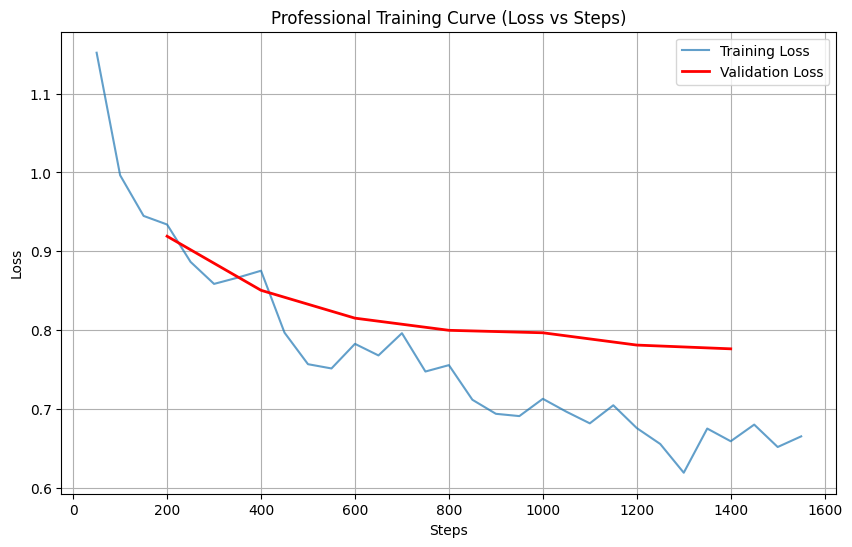

In [1]:
# =====================================================
# ⚡ 1. AGGRESSIVE WARNING SILENCER (MUST BE FIRST)
# =====================================================
import os
import warnings
import logging

# Filter confusing "Tokenizer" deprecation warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()  # Only show fatal errors
hf_logging.enable_explicit_format()

print("✅ System: Warnings silenced. Ready for training.")

# =====================================================
# 2. IMPORTS & SETUP
# =====================================================
import torch
import json
import sys
import numpy as np
import matplotlib.pyplot as plt
import evaluate
from datasets import Dataset
from transformers import (
    AutoModelForSeq2SeqLM, 
    AutoTokenizer, 
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer, 
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType

# CONFIGURATION
model_id = "facebook/nllb-200-distilled-600M"
output_dir = "./nllb-checkpoints"
final_model_dir = "./nllb-finetuned-tamil"
dataset_file = "nllb_bidir_dataset1.jsonl"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Hardware: {device.upper()}")

# Load Metrics (Ensure these libraries are installed)
try:
    bleu_metric = evaluate.load("sacrebleu")
    chrf_metric = evaluate.load("chrf")
except ImportError:
    print("❌ Error: Missing libraries. Run: pip install sacrebleu chrf evaluate matplotlib")
    sys.exit()

# =====================================================
# 3. DATA LOADING & CLEANING
# =====================================================
def load_clean_data(filename):
    if not os.path.exists(filename):
        print(f"❌ Error: {filename} not found.")
        sys.exit()
        
    data = []
    print(f"Reading {filename}...")
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try:
                entry = json.loads(line)
                if "src" in entry and "tgt" in entry:
                    data.append(entry)
            except:
                continue
    print(f"✅ Loaded {len(data)} valid rows.")
    return data

raw_data = load_clean_data(dataset_file)
full_dataset = Dataset.from_list(raw_data)

# SPLIT 80% Train / 20% Test
dataset_split = full_dataset.train_test_split(test_size=0.2, seed=42)

# =====================================================
# ⚡⚡⚡ SPEED OPTIMIZATION: USE ONLY 100 TEST SAMPLES ⚡⚡⚡
# =====================================================
print(f"📊 Original Test Size: {len(dataset_split['test'])}")
test_dataset = dataset_split["test"].select(range(100)) # <--- ONLY 100 SAMPLES
print(f"⚡ Optimized Test Size: {len(test_dataset)} (Faster Evaluation)")

dataset = {
    "train": dataset_split["train"],
    "test": test_dataset
}
# =====================================================

# =====================================================
# 4. TOKENIZATION
# =====================================================
tokenizer = AutoTokenizer.from_pretrained(model_id)

def preprocess_function(example):
    tokenizer.src_lang = example["src_lang"]
    inputs = tokenizer(example["src"], max_length=128, truncation=True)
    
    tokenizer.src_lang = example["tgt_lang"]
    targets = tokenizer(example["tgt"], max_length=128, truncation=True)
    
    inputs["labels"] = targets["input_ids"]
    return inputs

tokenized_train = dataset["train"].map(preprocess_function, batched=False, remove_columns=dataset["train"].column_names)
tokenized_test = dataset["test"].map(preprocess_function, batched=False, remove_columns=dataset["test"].column_names)

# =====================================================
# 5. METRICS FUNCTION
# =====================================================
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple): preds = preds[0]
    
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [[l.strip()] for l in decoded_labels]

    bleu = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels)
    chrf = chrf_metric.compute(predictions=decoded_preds, references=decoded_labels)

    return {"bleu": bleu["score"], "chrf": chrf["score"]}

# =====================================================
# 6. MODEL & TRAINING SETUP
# =====================================================
# Cleanup memory before loading
torch.cuda.empty_cache()

model = AutoModelForSeq2SeqLM.from_pretrained(model_id, torch_dtype=torch.float16, low_cpu_mem_usage=True).to(device)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM, inference_mode=False, r=32, lora_alpha=32, lora_dropout=0.1,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj", "fc1", "fc2"]
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="steps",            # UPDATED: 'evaluation_strategy' is deprecated
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    logging_steps=50,
    learning_rate=2e-4,
    
    # --- MEMORY OPTIMIZATION ---
    per_device_train_batch_size=2,    # Reduced from 4 (Prevents Crash)
    per_device_eval_batch_size=2,     # Reduced from 4
    gradient_accumulation_steps=8,    # Increased to maintain speed (Effective Batch = 16)
    # ---------------------------
    
    num_train_epochs=4,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    predict_with_generate=True,       # Required for BLEU
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,      # Using the smaller 100-sample test set
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
    processing_class=tokenizer,       # UPDATED: Replaces 'tokenizer' arg to fix warning
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("\n🚀 Starting Training (Batch Size 2, Accumulation 8)...")
trainer.train()

# =====================================================
# 7. SAVE & PLOT
# =====================================================
print(f"💾 Saving Best Model to {final_model_dir}...")
trainer.save_model(final_model_dir)
tokenizer.save_pretrained(final_model_dir)

# Professional Plotting Logic
history = trainer.state.log_history
train_steps = [x["step"] for x in history if "loss" in x]
train_loss = [x["loss"] for x in history if "loss" in x]
eval_steps = [x["step"] for x in history if "eval_loss" in x]
eval_loss = [x["eval_loss"] for x in history if "eval_loss" in x]

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", alpha=0.7)
plt.plot(eval_steps, eval_loss, label="Validation Loss", linewidth=2, color='red')
plt.title("Professional Training Curve (Loss vs Steps)")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_loss_graph.png")
print("📈 Graph saved: training_loss_graph.png")

✅ System: Warnings silenced. Ready for professional training.
✅ Hardware: CUDA
Reading nllb_bidir_dataset1.jsonl...
✅ Loaded 7956 valid rows.
📊 Original Test Size: 1592
⚡ Optimized Test Size: 100 (Fast Evaluation)


Map: 100%|██████████| 100/100 [00:00<00:00, 2457.94 examples/s]


trainable params: 17,301,504 || all params: 632,375,296 || trainable%: 2.7360

🚀 Starting Professional Training (Epochs: 15, Patience: 3)...
{'loss': 1.1513, 'grad_norm': 2.0870373249053955, 'learning_rate': 0.00019832073887489506, 'epoch': 0.1257071024512885}
{'loss': 0.9956, 'grad_norm': 2.7906455993652344, 'learning_rate': 0.0001966414777497901, 'epoch': 0.251414204902577}
{'loss': 0.9427, 'grad_norm': 3.3316843509674072, 'learning_rate': 0.00019496221662468514, 'epoch': 0.3771213073538655}
{'loss': 0.9308, 'grad_norm': 3.3079583644866943, 'learning_rate': 0.0001932829554995802, 'epoch': 0.502828409805154}
{'eval_loss': 0.9159035682678223, 'eval_bleu': 33.01849714085976, 'eval_chrf': 62.11069173750442, 'eval_runtime': 66.1113, 'eval_samples_per_second': 1.513, 'eval_steps_per_second': 0.756, 'epoch': 0.502828409805154}
{'loss': 0.8833, 'grad_norm': 3.2461318969726562, 'learning_rate': 0.00019160369437447525, 'epoch': 0.6285355122564424}
{'loss': 0.8553, 'grad_norm': 3.20602512359619

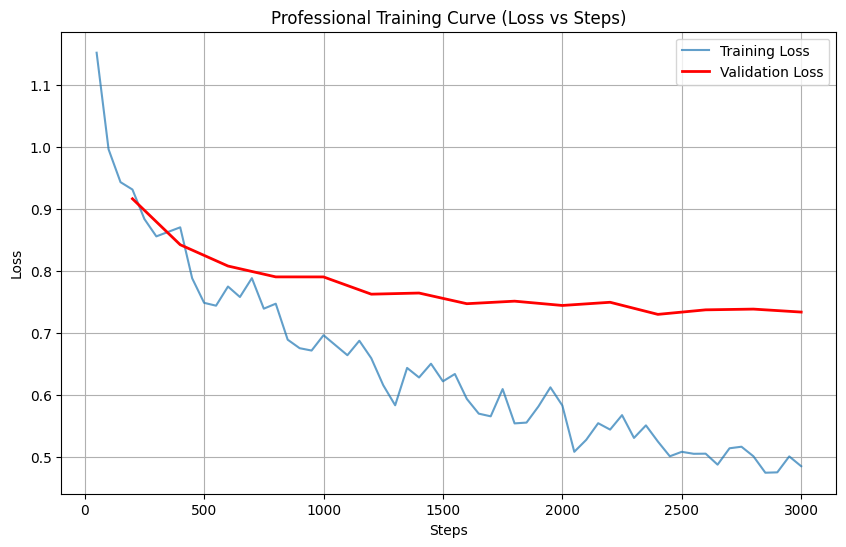

In [2]:
# =====================================================
# ⚡ 1. AGGRESSIVE WARNING SILENCER (MUST BE FIRST)
# =====================================================
import os
import warnings
import logging

# Filter confusing "Tokenizer" deprecation warnings & Tensorflow logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()  # Only show fatal errors
hf_logging.enable_explicit_format()

print("✅ System: Warnings silenced. Ready for professional training.")

# =====================================================
# 2. IMPORTS & SETUP
# =====================================================
import torch
import json
import sys
import numpy as np
import matplotlib.pyplot as plt
import evaluate
from datasets import Dataset
from transformers import (
    AutoModelForSeq2SeqLM, 
    AutoTokenizer, 
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer, 
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType

# CONFIGURATION
model_id = "facebook/nllb-200-distilled-600M"
output_dir = "./nllb-checkpoints"
final_model_dir = "./nllb-finetuned-tamil"
dataset_file = "nllb_bidir_dataset1.jsonl"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Hardware: {device.upper()}")

# Load Metrics (Ensure these libraries are installed)
try:
    bleu_metric = evaluate.load("sacrebleu")
    chrf_metric = evaluate.load("chrf")
except ImportError:
    print("❌ Error: Missing libraries. Run: pip install sacrebleu chrf evaluate matplotlib")
    sys.exit()

# =====================================================
# 3. DATA LOADING & CLEANING
# =====================================================
def load_clean_data(filename):
    if not os.path.exists(filename):
        print(f"❌ Error: {filename} not found.")
        sys.exit()
        
    data = []
    print(f"Reading {filename}...")
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try:
                entry = json.loads(line)
                if "src" in entry and "tgt" in entry:
                    data.append(entry)
            except:
                continue
    print(f"✅ Loaded {len(data)} valid rows.")
    return data

raw_data = load_clean_data(dataset_file)
full_dataset = Dataset.from_list(raw_data)

# SPLIT 80% Train / 20% Test
dataset_split = full_dataset.train_test_split(test_size=0.2, seed=42)

# =====================================================
# ⚡⚡⚡ SPEED OPTIMIZATION: USE ONLY 100 TEST SAMPLES ⚡⚡⚡
# =====================================================
# We use the full 20% for final testing, but only 100 for the training loop checks.
print(f"📊 Original Test Size: {len(dataset_split['test'])}")
test_dataset = dataset_split["test"].select(range(min(100, len(dataset_split['test'])))) 
print(f"⚡ Optimized Test Size: {len(test_dataset)} (Fast Evaluation)")

dataset = {
    "train": dataset_split["train"],
    "test": test_dataset
}
# =====================================================

# =====================================================
# 4. TOKENIZATION
# =====================================================
tokenizer = AutoTokenizer.from_pretrained(model_id)

def preprocess_function(example):
    tokenizer.src_lang = example["src_lang"]
    inputs = tokenizer(example["src"], max_length=128, truncation=True)
    
    tokenizer.src_lang = example["tgt_lang"]
    targets = tokenizer(example["tgt"], max_length=128, truncation=True)
    
    inputs["labels"] = targets["input_ids"]
    return inputs

tokenized_train = dataset["train"].map(preprocess_function, batched=False, remove_columns=dataset["train"].column_names)
tokenized_test = dataset["test"].map(preprocess_function, batched=False, remove_columns=dataset["test"].column_names)

# =====================================================
# 5. METRICS FUNCTION
# =====================================================
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple): preds = preds[0]
    
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [[l.strip()] for l in decoded_labels]

    bleu = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels)
    chrf = chrf_metric.compute(predictions=decoded_preds, references=decoded_labels)

    return {"bleu": bleu["score"], "chrf": chrf["score"]}

# =====================================================
# 6. MODEL & TRAINING SETUP
# =====================================================
# Cleanup memory before loading
torch.cuda.empty_cache()

model = AutoModelForSeq2SeqLM.from_pretrained(model_id, torch_dtype=torch.float16, low_cpu_mem_usage=True).to(device)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM, inference_mode=False, r=32, lora_alpha=32, lora_dropout=0.1,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj", "fc1", "fc2"]
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="steps",            # Check performance periodically
    eval_steps=200,                   # Check every 200 steps
    save_strategy="steps",
    save_steps=200,
    logging_steps=50,
    learning_rate=2e-4,
    
    # --- MEMORY OPTIMIZATION ---
    per_device_train_batch_size=2,    # Safe for most GPUs
    per_device_eval_batch_size=2,     
    gradient_accumulation_steps=8,    # Effective Batch Size = 16
    # ---------------------------
    
    num_train_epochs=15,              # ⚡ Set HIGH (15) and let Early Stopping handle it
    fp16=True,
    load_best_model_at_end=True,      # Always keep the best checkpoint
    metric_for_best_model="eval_loss",
    greater_is_better=False,          # Lower loss is better
    save_total_limit=2,
    predict_with_generate=True,       # Required for BLEU
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,      # Uses the small 100-sample set
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
    processing_class=tokenizer,       # Correct argument name
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # ⚡ Stops if no improvement for 3 checks
)

print("\n🚀 Starting Professional Training (Epochs: 15, Patience: 3)...")
trainer.train()

# =====================================================
# 7. SAVE & PLOT
# =====================================================
print(f"💾 Saving Best Model to {final_model_dir}...")
trainer.save_model(final_model_dir)
tokenizer.save_pretrained(final_model_dir)

# Professional Plotting Logic
history = trainer.state.log_history
train_steps = [x["step"] for x in history if "loss" in x]
train_loss = [x["loss"] for x in history if "loss" in x]
eval_steps = [x["step"] for x in history if "eval_loss" in x]
eval_loss = [x["eval_loss"] for x in history if "eval_loss" in x]

plt.figure(figsize=(10, 6))
if len(train_steps) > 0 and len(train_loss) > 0:
    plt.plot(train_steps, train_loss, label="Training Loss", alpha=0.7)
if len(eval_steps) > 0 and len(eval_loss) > 0:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", linewidth=2, color='red')

plt.title("Professional Training Curve (Loss vs Steps)")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_loss_graph.png")
print("📈 Graph saved: training_loss_graph.png")

In [4]:
# ==========================================
# STEP 1: MERGE LORA ADAPTER
# ==========================================
import torch
import os
import shutil
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# PATHS
adapter_path = "./nllb-finetuned-tamil"       # Your training output
base_model_id = "facebook/nllb-200-distilled-600M"
merged_output_path = "./nllb-merged"

# Cleanup previous merge if exists to avoid corruption
if os.path.exists(merged_output_path):
    shutil.rmtree(merged_output_path)

print("🔄 Loading base model...")
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    base_model_id, 
    torch_dtype=torch.float16, 
    low_cpu_mem_usage=True
)

print("🔗 Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, adapter_path)

print("⚡ Merging adapter into base model...")
model = model.merge_and_unload()

print(f"💾 Saving merged model to {merged_output_path}...")
model.save_pretrained(merged_output_path)
tokenizer = AutoTokenizer.from_pretrained(adapter_path)
tokenizer.save_pretrained(merged_output_path)

print("✅ Step 1 Complete: Model merged successfully.")

🔄 Loading base model...
🔗 Loading LoRA adapters...
⚡ Merging adapter into base model...
💾 Saving merged model to ./nllb-merged...
✅ Step 1 Complete: Model merged successfully.


In [5]:
!ct2-transformers-converter --model ./nllb-merged --quantization int8 --output_dir ./nllb-quantized-int8 --force

In [6]:
# ==========================================
# FILE: inference_engine.py
# ==========================================
import ctranslate2
import transformers
import os

class TamilTranslator:
    def __init__(self, model_folder="./nllb-quantized-int8", tokenizer_folder="./nllb-merged"):
        # 1. VERIFY PATHS
        if not os.path.exists(model_folder):
            raise FileNotFoundError(f"❌ Error: Model folder '{model_folder}' not found. Did you run Step 2?")
        
        if not os.path.exists(os.path.join(model_folder, "model.bin")):
             raise FileNotFoundError(f"❌ Error: 'model.bin' missing in '{model_folder}'. Conversion failed.")

        # 2. DETECT HARDWARE
        device = "cuda" if ctranslate2.get_cuda_device_count() > 0 else "cpu"
        print(f"🚀 Loading Translator on {device.upper()}...")

        # 3. LOAD MODEL
        try:
            self.translator = ctranslate2.Translator(model_folder, device=device)
            self.tokenizer = transformers.AutoTokenizer.from_pretrained(tokenizer_folder)
        except Exception as e:
            raise RuntimeError(f"❌ Failed to load model: {e}")

        print("✅ Model loaded successfully!")

    def translate(self, text, src_lang="eng_Latn", tgt_lang="tam_Taml"):
        if not text: return ""
        
        # Tokenize
        self.tokenizer.src_lang = src_lang
        source = self.tokenizer.convert_ids_to_tokens(self.tokenizer.encode(text))
        
        # Translate
        results = self.translator.translate_batch([source], target_prefix=[[tgt_lang]])
        
        # Decode
        target = results[0].hypotheses[0]
        return self.tokenizer.decode(self.tokenizer.convert_tokens_to_ids(target))

# Test it immediately if running this script directly
if __name__ == "__main__":
    engine = TamilTranslator()
    print("Test Translation:", engine.translate("Hello world"))

🚀 Loading Translator on CUDA...
✅ Model loaded successfully!
Test Translation: tam_Taml வணக்கம் உலகம்


In [9]:
import os
import shutil
import torch
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# ==========================================
# CONFIGURATION
# ==========================================
ADAPTER_PATH = "./nllb-finetuned-tamil"       # Your training output folder
BASE_MODEL = "facebook/nllb-200-distilled-600M"
MERGED_DIR = "./nllb-merged"
QUANTIZED_DIR = "./nllb-quantized-int8"

def main():
    # 1. CLEANUP PREVIOUS RUNS
    if os.path.exists(MERGED_DIR):
        shutil.rmtree(MERGED_DIR)
    if os.path.exists(QUANTIZED_DIR):
        shutil.rmtree(QUANTIZED_DIR)

    # 2. MERGE LORA ADAPTER
    print("🔄 Loading Base Model & Adapter...")
    base_model = AutoModelForSeq2SeqLM.from_pretrained(
        BASE_MODEL, 
        torch_dtype=torch.float16, 
        low_cpu_mem_usage=True
    )
    
    # Load adapter and fuse it
    model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
    model = model.merge_and_unload()

    print(f"💾 Saving Merged Model to {MERGED_DIR}...")
    model.save_pretrained(MERGED_DIR)
    
    # Save Tokenizer (Crucial for CTranslate2)
    tokenizer = AutoTokenizer.from_pretrained(ADAPTER_PATH)
    tokenizer.save_pretrained(MERGED_DIR)

    # 3. RUN QUANTIZATION (CTranslate2)
    print("🚀 Running CTranslate2 Quantization...")
    
    # We run the terminal command from inside Python
    command = (
        f"ct2-transformers-converter --model {MERGED_DIR} "
        f"--quantization int8 --output_dir {QUANTIZED_DIR} --force"
    )
    
    exit_code = os.system(command)
    
    if exit_code == 0:
        print(f"\n✅ SUCCESS! Quantized model is ready at: {QUANTIZED_DIR}")
        print("You can now run 'app.py'")
    else:
        print("\n❌ ERROR: Quantization failed. Check if 'ctranslate2' is installed.")

if __name__ == "__main__":
    main()

🔄 Loading Base Model & Adapter...
💾 Saving Merged Model to ./nllb-merged...
🚀 Running CTranslate2 Quantization...

✅ SUCCESS! Quantized model is ready at: ./nllb-quantized-int8
You can now run 'app.py'


In [14]:
import ctranslate2
import transformers
import os
import torch
import gc

class TamilTranslator:
    def __init__(self, model_dir="./nllb-quantized-int8", tokenizer_dir="./nllb-merged"):
        # 1. VERIFY PATHS
        if not os.path.exists(os.path.join(model_dir, "model.bin")):
            raise FileNotFoundError(f"❌ Error: Model not found at {model_dir}.")

        # 2. AGGRESSIVE MEMORY CLEANUP (Fixes OOM)
        print("🧹 Cleaning GPU memory...")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        # 3. TRY LOADING ON GPU, FALLBACK TO CPU
        self.tokenizer = transformers.AutoTokenizer.from_pretrained(tokenizer_dir)
        
        try:
            # Attempt CUDA Load
            if ctranslate2.get_cuda_device_count() > 0:
                print("⚡ Attempting to load on GPU (CUDA)...")
                self.translator = ctranslate2.Translator(model_dir, device="cuda")
                self.device = "cuda"
            else:
                raise RuntimeError("No GPU available")
                
        except RuntimeError as e:
            # Fallback if GPU is full or unavailable
            print(f"⚠️ GPU Load Failed ({e}). Switching to CPU...")
            self.translator = ctranslate2.Translator(model_dir, device="cpu")
            self.device = "cpu"

        print(f"✅ Model Loaded Successfully on: {self.device.upper()}")

    def translate(self, text, src_lang="eng_Latn", tgt_lang="tam_Taml"):
        if not text: return ""

        self.tokenizer.src_lang = src_lang
        source = self.tokenizer.convert_ids_to_tokens(self.tokenizer.encode(text))

        # Run Translation
        results = self.translator.translate_batch(
            [source], 
            target_prefix=[[tgt_lang]],
            beam_size=4
        )

        target_tokens = results[0].hypotheses[0]
        return self.tokenizer.decode(self.tokenizer.convert_tokens_to_ids(target_tokens))

# ==========================================
# TEST RUN
# ==========================================
if __name__ == "__main__":
    app = TamilTranslator()
    
    print("\n" + "="*30)
    print(f"⚙️ Final Device: {app.device}")
    
    res = app.translate("Deep learning requires a lot of memory.")
    print(f"🇱🇰 Result: {res}")
    print("="*30)

🧹 Cleaning GPU memory...
⚡ Attempting to load on GPU (CUDA)...
✅ Model Loaded Successfully on: CUDA

⚙️ Final Device: cuda
🇱🇰 Result: tam_Taml ஆழமான கற்றலுக்கு நிறைய நினைவாற்றல் தேவை.


In [15]:
import os
import shutil
from transformers import AutoTokenizer

# ==========================================
# CONFIGURATION
# ==========================================
BASE_MODEL = "facebook/nllb-200-distilled-600M"
OUTPUT_DIR = "./nllb-600m-int8"

def main():
    # 1. CLEANUP PREVIOUS RUNS
    if os.path.exists(OUTPUT_DIR):
        print(f"🧹 Cleaning up existing directory: {OUTPUT_DIR}")
        shutil.rmtree(OUTPUT_DIR)

    print(f"🚀 Starting Quantization for Base Model: {BASE_MODEL}")
    print("⏳ This converts the model directly to CTranslate2 int8 format...")

    # 2. RUN CTRANSLATE2 CONVERTER
    # We use the official command line tool via os.system
    command = (
        f"ct2-transformers-converter --model {BASE_MODEL} "
        f"--quantization int8 --output_dir {OUTPUT_DIR} --force"
    )
    
    exit_code = os.system(command)

    # 3. SAVE TOKENIZER
    # CTranslate2 needs the original tokenizer to prepare text
    if exit_code == 0:
        print("\n📖 Saving Tokenizer for inference...")
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
        tokenizer.save_pretrained(OUTPUT_DIR)
        
        print(f"\n✅ SUCCESS! Model is ready at: {OUTPUT_DIR}")
        print("You can now run 'inference.py'")
    else:
        print("\n❌ ERROR: Conversion failed. Make sure 'ctranslate2' and 'transformers' are installed.")

if __name__ == "__main__":
    main()

🚀 Starting Quantization for Base Model: facebook/nllb-200-distilled-600M
⏳ This converts the model directly to CTranslate2 int8 format...

📖 Saving Tokenizer for inference...

✅ SUCCESS! Model is ready at: ./nllb-600m-int8
You can now run 'inference.py'


In [4]:
import os
import torch
import json
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from peft import PeftModel
import evaluate

# ==========================================
# 1. SETUP (CPU MODE)
# ==========================================
device = "cpu"
print(f"=== 🛡️ Checking BLEU Score on {device.upper()} (Robust Mode) ===")

base_model_id = "facebook/nllb-200-distilled-600M"
adapter_path = "./nllb-legal-final"
test_file = "translation_test_pairs_50.json"

# ==========================================
# 2. LOAD MODEL
# ==========================================
print("⏳ Loading Model...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id)
model = PeftModel.from_pretrained(model, adapter_path)
model.eval()

bleu = evaluate.load("sacrebleu")

# ==========================================
# 3. ROBUST TRANSLATION FUNCTION
# ==========================================
def get_bleu_score(data, src_key, tgt_key, src_code, tgt_code):
    print(f"\n📊 Evaluating: {src_key} -> {tgt_key} ...")
    
    predictions = []
    references = []
    
    # Process each sentence
    for i, item in enumerate(data):
        # --- SAFETY CHECK ---
        # If the keys are missing, print the error and SKIP the row
        if src_key not in item:
            print(f"⚠️ SKIPPING Row {i}: Missing key '{src_key}'. Found: {list(item.keys())}")
            continue
        if tgt_key not in item:
            print(f"⚠️ SKIPPING Row {i}: Missing key '{tgt_key}'. Found: {list(item.keys())}")
            continue
            
        src_text = item[src_key]
        tgt_text = item[tgt_key]
        
        # 1. Tokenize
        tokenizer.src_lang = src_code
        inputs = tokenizer(src_text, return_tensors="pt", padding=False, truncation=True, max_length=128)
        
        # 2. Translate
        with torch.no_grad():
            generated = model.generate(
                **inputs,
                forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_code),
                max_length=128,
                num_beams=4,
                early_stopping=True
            )
            
        # 3. Decode
        pred = tokenizer.decode(generated[0], skip_special_tokens=True)
        predictions.append(pred)
        references.append([tgt_text])
        
        if i % 10 == 0: print(f"   Processed {i}/{len(data)}")

    # 4. Calculate Score
    if len(predictions) > 0:
        results = bleu.compute(predictions=predictions, references=references)
        print(f"✅ BLEU Score: {results['score']:.2f}")
        return results['score']
    else:
        print("❌ No valid predictions generated.")
        return 0.0

# ==========================================
# 4. RUN CHECK
# ==========================================
if not os.path.exists(test_file):
    print(f"❌ Error: {test_file} not found.")
else:
    with open(test_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        # Handle cases where data is a list directly OR a dict with "pairs"
        if isinstance(data, dict) and "pairs" in data:
            pairs = data['pairs']
        elif isinstance(data, list):
            pairs = data
        else:
            print("❌ JSON structure unknown. Expected list or {'pairs': [...]}")
            pairs = []

    if len(pairs) > 0:
        print(f"✅ Loaded {len(pairs)} test sentences.")

        # 1. Tamil -> English
        score_te = get_bleu_score(pairs, "tamil", "english", "tam_Taml", "eng_Latn")

        # 2. English -> Tamil
        score_et = get_bleu_score(pairs, "english", "tamil", "eng_Latn", "tam_Taml")

        print("\n" + "="*30)
        print(f"🏆 FINAL SCORES")
        print(f"Tamil -> English: {score_te:.2f}")
        print(f"English -> Tamil: {score_et:.2f}")
        print("="*30)

=== 🛡️ Checking BLEU Score on CPU (Robust Mode) ===
⏳ Loading Model...
✅ Loaded 60 test sentences.

📊 Evaluating: tamil -> english ...
   Processed 0/60
   Processed 10/60
   Processed 20/60
   Processed 30/60
   Processed 40/60
   Processed 50/60
✅ BLEU Score: 37.90

📊 Evaluating: english -> tamil ...
   Processed 0/60
   Processed 10/60
   Processed 20/60
   Processed 30/60
   Processed 40/60
   Processed 50/60
✅ BLEU Score: 20.69

🏆 FINAL SCORES
Tamil -> English: 37.90
English -> Tamil: 20.69


6. Evaluation the fine-tuned model

In [ ]:
# ==========================================
# AFTER TRAINING – SEQUENTIAL BIDIRECTIONAL EVALUATION
# ==========================================
import time
import json
import torch
import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel

# ==========================================
# DEVICE SETUP (CUDA → CPU FALLBACK)
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("🛡️ Using CPU")

# ==========================================
# CONFIG
# ==========================================
base_model_id = "facebook/nllb-200-distilled-600M"
adapter_path = "./nllb-legal-final"
test_file = "translation_test_pairs_50.json"

# ==========================================
# LOAD MODEL (BASE + LoRA)
# ==========================================
print("⏳ Loading LoRA fine-tuned model...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id)
model = PeftModel.from_pretrained(base_model, adapter_path)

model = model.to(device)
model.eval()

bleu = evaluate.load("sacrebleu")
chrf = evaluate.load("chrf")

# ==========================================
# LOAD & NORMALIZE DATA
# ==========================================
with open(test_file, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

if isinstance(raw_data, dict) and "pairs" in raw_data:
    data = raw_data["pairs"]
elif isinstance(raw_data, list):
    data = raw_data
else:
    raise ValueError("❌ Unsupported JSON structure")

print(f"✅ Loaded {len(data)} test samples")

# ==========================================================
# 1️⃣ FULL DATASET EVALUATION: TAMIL → ENGLISH
# ==========================================================
print("\n==============================")
print("🔁 FULL EVALUATION: Tamil → English")
print("==============================")

SRC_KEY = "tamil"
TGT_KEY = "english"
SRC_LANG = "tam_Taml"
TGT_LANG = "eng_Latn"

predictions = []
references = []
total_time = 0.0
valid_count = 0

for row in data:
    if not isinstance(row, dict):
        continue
    if SRC_KEY not in row or TGT_KEY not in row:
        continue

    tokenizer.src_lang = SRC_LANG
    inputs = tokenizer(
        row[SRC_KEY],
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    if device == "cuda":
        torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(TGT_LANG),
            max_length=128,
            num_beams=4,
            use_cache=True
        )

    if device == "cuda":
        torch.cuda.synchronize()
    end = time.time()

    total_time += (end - start)

    pred = tokenizer.decode(output[0], skip_special_tokens=True)
    predictions.append(pred)
    references.append([row[TGT_KEY]])
    valid_count += 1

bleu_te = bleu.compute(predictions=predictions, references=references)["score"]
chrf_te = chrf.compute(predictions=predictions, references=references)["score"]
latency_te = total_time / valid_count

print(f"Samples Evaluated : {valid_count}")
print(f"BLEU              : {bleu_te:.2f}")
print(f"CHRF++            : {chrf_te:.2f}")
print(f"Avg Latency (sec) : {latency_te:.3f}")

# ==========================================================
# 2️⃣ FULL DATASET EVALUATION: ENGLISH → TAMIL
# ==========================================================
print("\n==============================")
print("🔁 FULL EVALUATION: English → Tamil")
print("==============================")

SRC_KEY = "english"
TGT_KEY = "tamil"
SRC_LANG = "eng_Latn"
TGT_LANG = "tam_Taml"

predictions = []
references = []
total_time = 0.0
valid_count = 0

for row in data:
    if not isinstance(row, dict):
        continue
    if SRC_KEY not in row or TGT_KEY not in row:
        continue

    tokenizer.src_lang = SRC_LANG
    inputs = tokenizer(
        row[SRC_KEY],
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    if device == "cuda":
        torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(TGT_LANG),
            max_length=128,
            num_beams=4,
            use_cache=True
        )

    if device == "cuda":
        torch.cuda.synchronize()
    end = time.time()

    total_time += (end - start)

    pred = tokenizer.decode(output[0], skip_special_tokens=True)
    predictions.append(pred)
    references.append([row[TGT_KEY]])
    valid_count += 1

bleu_et = bleu.compute(predictions=predictions, references=references)["score"]
chrf_et = chrf.compute(predictions=predictions, references=references)["score"]
latency_et = total_time / valid_count

print(f"Samples Evaluated : {valid_count}")
print(f"BLEU              : {bleu_et:.2f}")
print(f"CHRF++            : {chrf_et:.2f}")
print(f"Avg Latency (sec) : {latency_et:.3f}")

# ==========================================================
# FINAL SUMMARY
# ==========================================================
print("\n==============================")
print("🏁 FINAL BIDIRECTIONAL SUMMARY")
print("==============================")
print(f"Tamil → English | BLEU: {bleu_te:.2f} | CHRF++: {chrf_te:.2f}")
print(f"English → Tamil | BLEU: {bleu_et:.2f} | CHRF++: {chrf_et:.2f}")
print("==============================")


🚀 Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
⏳ Loading LoRA fine-tuned model...
✅ Loaded 60 test samples

🔁 FULL EVALUATION: Tamil → English
Samples Evaluated : 60
BLEU              : 38.74
CHRF++            : 63.47
Avg Latency (sec) : 2.088

🔁 FULL EVALUATION: English → Tamil
Samples Evaluated : 60
BLEU              : 20.58
CHRF++            : 65.10
Avg Latency (sec) : 2.576

🏁 FINAL BIDIRECTIONAL SUMMARY
Tamil → English | BLEU: 38.74 | CHRF++: 63.47
English → Tamil | BLEU: 20.58 | CHRF++: 65.10


In [2]:
import torch
import time
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
# Use GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using Device: {device}")

model_id = "facebook/nllb-200-distilled-600M"

# NLLB Language Codes
LANG_CODE_ENGLISH = "eng_Latn"
LANG_CODE_SINHALA = "sin_Sinh"

# ==========================================
# 2. LOAD MODEL (Runs once)
# ==========================================
print("⏳ Loading NLLB model (this may take a moment)...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id).to(device)
model.eval()
print("✅ Model Loaded Successfully!")

# ==========================================
# 3. SAMPLE DATA (10 Pairs)
# ==========================================
# We use these pairs to test both directions
samples = [
    {"en": "Hello", "si": "ආයුබෝවන්"},
    {"en": "How are you?", "si": "ඔයාට කොහොමද?"},
    {"en": "I love Sri Lanka", "si": "මම ශ්‍රී ලංකාවට ආදරෙයි"},
    {"en": "Where is the bus station?", "si": "බස් නැවතුම්පොළ කොහෙද?"},
    {"en": "Can you help me?", "si": "ඔයාට මට උදව් කරන්න පුළුවන්ද?"},
    {"en": "The food is delicious", "si": "කෑම ගොඩක් රසයි"},
    {"en": "Good morning", "si": "සුබ උදෑසනක්"},
    {"en": "What is your name?", "si": "ඔයාගේ නම මොකද්ද?"},
    {"en": "I am going home", "si": "මම ගෙදර යනවා"},
    {"en": "Thank you very much", "si": "බොහොම ස්තූතියි"}
]

# ==========================================
# 4. TRANSLATION FUNCTION
# ==========================================
def run_translation_test(direction_name, src_lang, tgt_lang, data_key_src, data_key_tgt):
    print(f"\n==========================================")
    print(f"🧪 TESTING DIRECTION: {direction_name}")
    print(f"==========================================")
    
    start_total = time.time()
    
    for i, item in enumerate(samples):
        text_input = item[data_key_src]
        reference_text = item[data_key_tgt]

        # 1. Tokenize Input (Set Source Language)
        tokenizer.src_lang = src_lang
        inputs = tokenizer(text_input, return_tensors="pt", padding=True, truncation=True).to(device)

        # 2. Generate Translation (Force Target Language)
        # FIX IS HERE: We use convert_tokens_to_ids instead of lang_code_to_id
        forced_bos_token_id = tokenizer.convert_tokens_to_ids(tgt_lang)
        
        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                forced_bos_token_id=forced_bos_token_id, 
                max_length=100
            )

        # 3. Decode Output
        translated_text = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

        # 4. Print Result
        print(f"Sample {i+1}:")
        print(f"   Input ({src_lang}):  {text_input}")
        print(f"   Model Output:      {translated_text}")
        print(f"   Reference:         {reference_text}")
        print("-" * 40)

    end_total = time.time()
    print(f"✅ {direction_name} Testing Complete in {end_total - start_total:.2f} seconds.")

# ==========================================
# 5. RUN BIDIRECTIONAL TESTS
# ==========================================

# Test 1: English -> Sinhala
run_translation_test(
    direction_name="English -> Sinhala",
    src_lang=LANG_CODE_ENGLISH,  # eng_Latn
    tgt_lang=LANG_CODE_SINHALA,  # sin_Sinh
    data_key_src="en",
    data_key_tgt="si"
)

# Test 2: Sinhala -> English
run_translation_test(
    direction_name="Sinhala -> English",
    src_lang=LANG_CODE_SINHALA,  # sin_Sinh
    tgt_lang=LANG_CODE_ENGLISH,  # eng_Latn
    data_key_src="si",
    data_key_tgt="en"
)

🚀 Using Device: cuda
⏳ Loading NLLB model (this may take a moment)...
✅ Model Loaded Successfully!

🧪 TESTING DIRECTION: English -> Sinhala
Sample 1:
   Input (eng_Latn):  Hello
   Model Output:      හෙලෝ.
   Reference:         ආයුබෝවන්
----------------------------------------
Sample 2:
   Input (eng_Latn):  How are you?
   Model Output:      කොහොමද ඔයාට?
   Reference:         ඔයාට කොහොමද?
----------------------------------------
Sample 3:
   Input (eng_Latn):  I love Sri Lanka
   Model Output:      මම ශ් රී ලංකාවට ආදරෙයි.
   Reference:         මම ශ්‍රී ලංකාවට ආදරෙයි
----------------------------------------
Sample 4:
   Input (eng_Latn):  Where is the bus station?
   Model Output:      බස් නැවතුම කොහෙද?
   Reference:         බස් නැවතුම්පොළ කොහෙද?
----------------------------------------
Sample 5:
   Input (eng_Latn):  Can you help me?
   Model Output:      ඔයාට මට උදව් කරන්න පුලුවන්ද?
   Reference:         ඔයාට මට උදව් කරන්න පුළුවන්ද?
----------------------------------------
Sample 6:


7. RAG sentence-transfomer-testing for English

In [4]:
import json
import os
import faiss
import numpy as np
import pandas as pd
import torch
import re  # Added for text normalization
from sentence_transformers import SentenceTransformer

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Double slashes are fine, but using raw strings (r"...") is safer for Windows paths
INDEX_PATH = r"D://reserach-testing//index (1).faiss"
METADATA_PATH = r"D://reserach-testing//legal_data.jsonl"
TEST_FILE = r"D://reserach-testing//rag_retrval_testing.json"
MODEL_NAME = 'all-MiniLM-L6-v2'
TOP_K = 5

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def normalize(text):
    """
    Cleans text for comparison.
    Removes punctuation, extra spaces, and converts to lowercase.
    Example: "Bail Act, No. 30" -> "bail act no 30"
    """
    if not isinstance(text, str):
        return str(text).lower().strip()
    # Remove all non-alphanumeric characters (dots, commas, etc)
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower().strip()

def load_jsonl(path):
    """Loads JSONL metadata line by line."""
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

def load_json(path):
    """Loads standard JSON file."""
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

# ==========================================
# 3. SETUP & LOAD
# ==========================================

# Check if CUDA is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"⚙️  Hardware detected: {device.upper()}")

if not os.path.exists(INDEX_PATH) or not os.path.exists(METADATA_PATH):
    print(f"❌ Error: Could not find {INDEX_PATH} or {METADATA_PATH}.")
else:
    print(f"✅ Found files. Loading...")

    # 1. Load Metadata
    corpus_metadata = load_jsonl(METADATA_PATH) 
    
    # 2. Load Index and Handle GPU Transfer
    print("⏳ Loading FAISS index...")
    index = faiss.read_index(INDEX_PATH)
    
    if device == 'cuda':
        try:
            res = faiss.StandardGpuResources()
            # Move the index from CPU to GPU
            index = faiss.index_cpu_to_gpu(res, 0, index)
            print(f"✅ FAISS index moved to GPU (VRAM).")
        except AttributeError:
            print("⚠️  'faiss-gpu' not installed. Running FAISS on CPU (Model will still use GPU).")
        except Exception as e:
            print(f"⚠️  Could not move Index to GPU: {e}. Keeping on CPU.")

    # 3. Validation Check
    try:
        count = index.ntotal
    except:
        count = len(corpus_metadata)
        
    if count != len(corpus_metadata):
        print(f"⚠️ WARNING: Index has {count} vectors but Metadata has {len(corpus_metadata)} lines.")
    else:
        print(f"✅ Index loaded: {count} documents.")

    # 4. Load Test Questions
    test_queries = load_json(TEST_FILE)
    print(f"✅ Loaded {len(test_queries)} test questions.")

    # 5. Load Model
    print(f"⏳ Loading Model {MODEL_NAME} on {device.upper()}...")
    model = SentenceTransformer(MODEL_NAME, device=device)

    # ==========================================
    # 4. RUN EVALUATION
    # ==========================================
    print("🚀 Running Retrieval...")

    query_texts = [q['question'] for q in test_queries]
    
    query_embeddings = model.encode(
        query_texts, 
        convert_to_numpy=True, 
        show_progress_bar=True,
        batch_size=32
    )
    
    # Ensure float32 for Faiss
    query_embeddings = query_embeddings.astype('float32')

    # Normalize for Cosine Similarity
    faiss.normalize_L2(query_embeddings)

    # Search the Index
    distances, indices = index.search(query_embeddings, TOP_K)

    # Handle GPU return types
    if isinstance(indices, torch.Tensor):
        indices = indices.cpu().numpy()
    if isinstance(distances, torch.Tensor):
        distances = distances.cpu().numpy()
    
    indices = np.array(indices)
    distances = np.array(distances)

    # ==========================================
    # 5. CALCULATE METRICS (FIXED)
    # ==========================================
    hits = 0
    mrr_sum = 0
    results_data = []

    for i, query_obj in enumerate(test_queries):
        expected_ids = set(query_obj['expected_sections'])
        expected_source = query_obj['source_name']
        
        # Pre-normalize the expected source
        norm_expected_source = normalize(expected_source)
        
        retrieved_indices = indices[i]
        is_hit = False
        reciprocal_rank = 0
        retrieved_snippets = []

        for rank, doc_idx in enumerate(retrieved_indices):
            if doc_idx < len(corpus_metadata) and doc_idx >= 0:
                doc_info = corpus_metadata[doc_idx]
                
                r_source = doc_info.get('source name', 'Unknown')
                r_id = str(doc_info.get('sectionid', 'Unknown'))
                
                retrieved_snippets.append(f"{r_source} Sec {r_id}")

                # === FIX: Normalize retrieved source before comparing ===
                norm_r_source = normalize(r_source)
                
                # Check Match
                if (norm_r_source == norm_expected_source) and (r_id in expected_ids):
                    if not is_hit:
                        reciprocal_rank = 1 / (rank + 1)
                        is_hit = True
            else:
                retrieved_snippets.append(f"Error: Index {doc_idx} out of bounds")

        if is_hit:
            hits += 1
            mrr_sum += reciprocal_rank
        
        results_data.append({
            "Question ID": query_obj['id'],
            "Question": query_obj['question'],
            "Expected": f"{expected_source} Sec {list(expected_ids)}",
            "Hit": is_hit,
            "Rank": round(1/reciprocal_rank) if is_hit else 0,
            "Retrieved Top 5": str(retrieved_snippets)
        })

    # ==========================================
    # 6. DISPLAY RESULTS
    # ==========================================
    hit_rate = hits / len(test_queries)
    mrr = mrr_sum / len(test_queries)

    print("\n" + "="*40)
    print("📊 FINAL EVALUATION REPORT (FIXED)")
    print("="*40)
    print(f"Device Used:   {device.upper()}")
    print(f"Total Questions: {len(test_queries)}")
    print(f"Hit Rate @ {TOP_K}:    {hit_rate:.2%} (Target: >80%)")
    print(f"MRR Score:        {mrr:.4f} (Target: >0.70)")
    print("="*40)

    df = pd.DataFrame(results_data)
    
    # Filter failures
    failures = df[df['Hit'] == False]
    
    if not failures.empty:
        print("\n🔍 First 5 Failed Queries:")
        print(failures[['Question', 'Expected', 'Retrieved Top 5']].head().to_string())
    else:
        print("\n🎉 AMAZING! No failures found. 100% Accuracy.")

    df.to_csv("rag_test_results.csv", index=False)
    print("\n✅ Full results saved to 'rag_test_results.csv'")

⚙️  Hardware detected: CUDA
✅ Found files. Loading...
⏳ Loading FAISS index...
⚠️  'faiss-gpu' not installed. Running FAISS on CPU (Model will still use GPU).
✅ Index loaded: 1323 documents.
✅ Loaded 101 test questions.
⏳ Loading Model all-MiniLM-L6-v2 on CUDA...
🚀 Running Retrieval...


Batches: 100%|██████████| 4/4 [00:00<00:00, 30.33it/s]


📊 FINAL EVALUATION REPORT (FIXED)
Device Used:   CUDA
Total Questions: 101
Hit Rate @ 5:    83.17% (Target: >80%)
MRR Score:        0.7302 (Target: >0.70)

🔍 First 5 Failed Queries:
                                                                                                                                                    Question                                       Expected                                                                                                                                                                                 Retrieved Top 5
10                                                                               What are the three ways a person can be found guilty of 'abetting' a crime?                         Penal Code Sec ['100']                                          ['Penal Code Sec 101', 'Code of Criminal Procedure Act Sec 130', 'Code of Criminal Procedure Act Sec 177', 'Penal Code Sec 102', 'Penal Code Sec 192']
21  If a man kills a Fisc

In [6]:
import json
import os
import faiss
import numpy as np
import pandas as pd
import torch
import re
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ==========================================
# 1. CONFIGURATION
# ==========================================
INDEX_PATH = r"D://reserach-testing//index (1).faiss"
METADATA_PATH = r"D://reserach-testing//legal_data.jsonl"
TEST_FILE = r"D://reserach-testing//rag_retrval_tamil-testing.json"

EMBED_MODEL = "all-MiniLM-L6-v2"
NLLB_MODEL = "facebook/nllb-200-distilled-600M"

TOP_K = 5
SRC_LANG = "tam_Taml"
TGT_LANG = "eng_Latn"

# ==========================================
# 2. HELPERS
# ==========================================
def normalize(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[^\w\s]", "", text)
    return text.lower().strip()

def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

# ==========================================
# 3. DEVICE
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {device.upper()}")

# ==========================================
# 4. LOAD NLLB TRANSLATION MODEL
# ==========================================
print("⏳ Loading NLLB-600M translation model...")
tokenizer = AutoTokenizer.from_pretrained(NLLB_MODEL)
translator = AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL).to(device)

def translate_tamil_to_english(texts, batch_size=8):
    translations = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            generated = translator.generate(
                **inputs,
                forced_bos_token_id=tokenizer.convert_tokens_to_ids(TGT_LANG),
                max_length=256
            )

        outputs = tokenizer.batch_decode(generated, skip_special_tokens=True)
        translations.extend(outputs)
    return translations

# ==========================================
# 5. LOAD DATA
# ==========================================
corpus_metadata = load_jsonl(METADATA_PATH)
test_queries = load_json(TEST_FILE)

print(f"✅ Loaded {len(corpus_metadata)} corpus documents")
print(f"✅ Loaded {len(test_queries)} test queries")

# ==========================================
# 6. LOAD FAISS
# ==========================================
print("⏳ Loading FAISS index...")
index = faiss.read_index(INDEX_PATH)

if device == "cuda":
    try:
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
        print("✅ FAISS moved to GPU")
    except:
        print("⚠️ FAISS GPU not available, using CPU")

# ==========================================
# 7. LOAD EMBEDDING MODEL
# ==========================================
embedder = SentenceTransformer(EMBED_MODEL, device=device)

# ==========================================
# 8. TRANSLATE TAMIL QUESTIONS
# ==========================================
print("🌍 Translating Tamil → English using NLLB-600M...")
tamil_questions = [q["question"] for q in test_queries]
translated_questions = translate_tamil_to_english(tamil_questions)

# ==========================================
# 9. EMBEDDING + SEARCH
# ==========================================
query_embeddings = embedder.encode(
    translated_questions,
    convert_to_numpy=True,
    batch_size=32,
    show_progress_bar=True
).astype("float32")

faiss.normalize_L2(query_embeddings)
distances, indices = index.search(query_embeddings, TOP_K)

# ==========================================
# 10. METRICS
# ==========================================
hits = 0
mrr_sum = 0
rows = []

for i, q in enumerate(test_queries):
    expected_ids = set(q["expected_sections"])
    expected_source = normalize(q["source_name"])

    hit = False
    rr = 0
    retrieved = []

    for rank, idx in enumerate(indices[i]):
        if idx < 0 or idx >= len(corpus_metadata):
            continue

        doc = corpus_metadata[idx]
        src = normalize(doc.get("source name", ""))
        sec = str(doc.get("sectionid", ""))

        retrieved.append(f"{doc.get('source name')} Sec {sec}")

        if src == expected_source and sec in expected_ids and not hit:
            hit = True
            rr = 1 / (rank + 1)

    if hit:
        hits += 1
        mrr_sum += rr

    rows.append({
        "Question": q["question"],
        "Translated": translated_questions[i],
        "Expected": f"{q['source_name']} {expected_ids}",
        "Hit": hit,
        "MRR": rr,
        "Retrieved": retrieved
    })

# ==========================================
# 11. RESULTS
# ==========================================
hit_rate = hits / len(test_queries)
mrr = mrr_sum / len(test_queries)

print("\n========================================")
print("📊 FINAL NLLB-600M RETRIEVAL EVALUATION")
print("========================================")
print(f"Hit@{TOP_K}: {hit_rate:.2%}")
print(f"MRR:         {mrr:.4f}")
print("========================================")

df = pd.DataFrame(rows)
df.to_csv("nllb600m_tamil_retrieval_results.csv", index=False)
print("✅ Results saved: nllb600m_tamil_retrieval_results.csv")


🚀 Using device: CUDA
⏳ Loading NLLB-600M translation model...
✅ Loaded 1323 corpus documents
✅ Loaded 100 test queries
⏳ Loading FAISS index...
⚠️ FAISS GPU not available, using CPU
🌍 Translating Tamil → English using NLLB-600M...


Batches: 100%|██████████| 4/4 [00:00<00:00, 26.00it/s]


📊 FINAL NLLB-600M RETRIEVAL EVALUATION
Hit@5: 62.00%
MRR:         0.4612
✅ Results saved: nllb600m_tamil_retrieval_results.csv


In [7]:
import json
import faiss
import numpy as np
import pandas as pd
import torch
import re
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel

# ==========================================
# 1. CONFIGURATION
# ==========================================
INDEX_PATH = r"D://reserach-testing//index (1).faiss"
METADATA_PATH = r"D://reserach-testing//legal_data.jsonl"
TEST_FILE = r"D://reserach-testing//rag_retrval_tamil-testing.json"

EMBED_MODEL = "all-MiniLM-L6-v2"

BASE_MODEL_ID = "facebook/nllb-200-distilled-600M"
ADAPTER_PATH = "./nllb-legal-final"

TOP_K = 5
SRC_LANG = "tam_Taml"
TGT_LANG = "eng_Latn"

# ==========================================
# 2. HELPERS
# ==========================================
def normalize(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[^\w\s]", "", text)
    return text.lower().strip()

def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

# ==========================================
# 3. DEVICE
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {device.upper()}")

# ==========================================
# 4. LOAD FINE-TUNED NLLB (BASE + ADAPTER)
# ==========================================
print("⏳ Loading NLLB-600M base model...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL_ID).to(device)

print("🔗 Loading fine-tuned adapter...")
translator = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
translator.eval()

# ==========================================
# 5. TRANSLATION FUNCTION
# ==========================================
def translate_tamil_to_english(texts, batch_size=8):
    tokenizer.src_lang = SRC_LANG
    outputs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            generated = translator.generate(
                **inputs,
                forced_bos_token_id=tokenizer.convert_tokens_to_ids(TGT_LANG),
                max_length=256
            )

        decoded = tokenizer.batch_decode(
            generated, skip_special_tokens=True
        )
        outputs.extend(decoded)

    return outputs

# ==========================================
# 6. LOAD DATA
# ==========================================
corpus_metadata = load_jsonl(METADATA_PATH)
test_queries = load_json(TEST_FILE)

print(f"✅ Loaded {len(corpus_metadata)} corpus documents")
print(f"✅ Loaded {len(test_queries)} test queries")

# ==========================================
# 7. LOAD FAISS INDEX
# ==========================================
print("⏳ Loading FAISS index...")
index = faiss.read_index(INDEX_PATH)

if device == "cuda":
    try:
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
        print("✅ FAISS moved to GPU")
    except:
        print("⚠️ FAISS GPU not available, using CPU")

# ==========================================
# 8. LOAD EMBEDDING MODEL
# ==========================================
embedder = SentenceTransformer(EMBED_MODEL, device=device)

# ==========================================
# 9. TRANSLATE QUERIES
# ==========================================
print("🌍 Translating Tamil → English (FINE-TUNED NLLB)...")
tamil_questions = [q["question"] for q in test_queries]
translated_questions = translate_tamil_to_english(tamil_questions)

# ==========================================
# 10. EMBEDDING + SEARCH
# ==========================================
query_embeddings = embedder.encode(
    translated_questions,
    convert_to_numpy=True,
    batch_size=32,
    show_progress_bar=True
).astype("float32")

faiss.normalize_L2(query_embeddings)
distances, indices = index.search(query_embeddings, TOP_K)

# ==========================================
# 11. METRICS
# ==========================================
hits = 0
mrr_sum = 0
rows = []

for i, q in enumerate(test_queries):
    expected_ids = set(q["expected_sections"])
    expected_source = normalize(q["source_name"])

    hit = False
    rr = 0
    retrieved = []

    for rank, idx in enumerate(indices[i]):
        if idx < 0 or idx >= len(corpus_metadata):
            continue

        doc = corpus_metadata[idx]
        src = normalize(doc.get("source name", ""))
        sec = str(doc.get("sectionid", ""))

        retrieved.append(f"{doc.get('source name')} Sec {sec}")

        if src == expected_source and sec in expected_ids and not hit:
            hit = True
            rr = 1 / (rank + 1)

    if hit:
        hits += 1
        mrr_sum += rr

    rows.append({
        "Tamil Question": q["question"],
        "Translated EN": translated_questions[i],
        "Expected": f"{q['source_name']} {expected_ids}",
        "Hit": hit,
        "RR": rr,
        "Retrieved TopK": retrieved
    })

# ==========================================
# 12. RESULTS
# ==========================================
hit_rate = hits / len(test_queries)
mrr = mrr_sum / len(test_queries)

print("\n========================================")
print("📊 FINAL FINE-TUNED NLLB RETRIEVAL EVALUATION")
print("========================================")
print(f"Hit@{TOP_K}: {hit_rate:.2%}")
print(f"MRR:         {mrr:.4f}")
print("========================================")

df = pd.DataFrame(rows)
df.to_csv("finetuned_nllb_tamil_retrieval_results.csv", index=False)
print("✅ Results saved: finetuned_nllb_tamil_retrieval_results.csv")


🚀 Using device: CUDA
⏳ Loading NLLB-600M base model...


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 6e20c188-11cc-4e8c-b884-00e595e8a0e4)')' thrown while requesting HEAD https://huggingface.co/facebook/nllb-200-distilled-600M/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


🔗 Loading fine-tuned adapter...
✅ Loaded 1323 corpus documents
✅ Loaded 100 test queries
⏳ Loading FAISS index...
⚠️ FAISS GPU not available, using CPU
🌍 Translating Tamil → English (FINE-TUNED NLLB)...


Batches: 100%|██████████| 4/4 [00:00<00:00, 17.90it/s]


📊 FINAL FINE-TUNED NLLB RETRIEVAL EVALUATION
Hit@5: 75.00%
MRR:         0.6238
✅ Results saved: finetuned_nllb_tamil_retrieval_results.csv


In [1]:
import json
import os
import faiss
import numpy as np
import torch
from sentence_transformers import SentenceTransformer

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Input File
DATA_PATH = r"D://reserach-testing//legal_data.jsonl"

# Output File (Where to save the new index)
OUTPUT_INDEX_PATH = r"D://reserach-testing//index.faiss"

# Model Name (LegalBERT)
MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'

# Batch size (Reduce to 16 or 8 if you run out of memory)
BATCH_SIZE = 32

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"📂 Reading data from {DATA_PATH}...")

documents = []
search_texts = []

if not os.path.exists(DATA_PATH):
    print(f"❌ Error: File not found at {DATA_PATH}")
    exit()

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if line.strip():
            try:
                doc = json.loads(line)
                documents.append(doc)
                
                # --- CRITICAL: FORMATTING TEXT FOR EMBEDDING ---
                # We combine Source, Section ID, Title, and Content into one string.
                # This ensures the model understands the context of the law.
                combined_text = (
                    f"LAW: {doc.get('source name', '')}\n"
                    f"SECTION: {doc.get('sectionid', '')}\n"
                    f"TITLE: {doc.get('title', '')}\n"
                    f"CONTENT: {doc.get('content', '')}"
                )
                search_texts.append(combined_text)
                
            except json.JSONDecodeError:
                print(f"⚠️ Skipping invalid JSON at line {i}")

print(f"✅ Loaded {len(search_texts)} documents.")

# ==========================================
# 3. INITIALIZE MODEL
# ==========================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"⚙️  Loading {MODEL_NAME} on {device.upper()}...")

# Load LegalBERT via SentenceTransformers
model = SentenceTransformer(MODEL_NAME, device=device)

# ==========================================
# 4. GENERATE EMBEDDINGS
# ==========================================
print("⏳ Generating embeddings (this may take a while)...")

# Convert texts to vectors
embeddings = model.encode(
    search_texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"✅ Embeddings shape: {embeddings.shape}") 
# Expected shape: (num_documents, 768)

# ==========================================
# 5. BUILD FAISS INDEX
# ==========================================
print("🏗️  Building FAISS Index...")

# 1. Normalize vectors (Important for Cosine Similarity / Retrieval accuracy)
faiss.normalize_L2(embeddings)

# 2. Create Index
# LegalBERT outputs 768 dimensions
dimension = embeddings.shape[1] 
index = faiss.IndexFlatL2(dimension) # L2 Distance index

# 3. Add vectors to index
index.add(embeddings)

print(f"✅ Index built with {index.ntotal} vectors.")

# ==========================================
# 6. SAVE INDEX
# ==========================================
print(f"💾 Saving index to {OUTPUT_INDEX_PATH}...")
faiss.write_index(index, OUTPUT_INDEX_PATH)

print("\n🎉 DONE! You can now run the evaluation script.")

d:\reserach-testing\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📂 Reading data from D://reserach-testing//legal_data.jsonl...
✅ Loaded 1323 documents.
⚙️  Loading nlpaueb/legal-bert-base-uncased on CUDA...


No sentence-transformers model found with name nlpaueb/legal-bert-base-uncased. Creating a new one with mean pooling.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
d:\reserach-testing\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sivaj\.cache\huggingface\hub\models--nlpaueb--legal-bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need 

⏳ Generating embeddings (this may take a while)...


Batches: 100%|██████████| 42/42 [00:20<00:00,  2.03it/s]

✅ Embeddings shape: (1323, 768)
🏗️  Building FAISS Index...
✅ Index built with 1323 vectors.
💾 Saving index to D://reserach-testing//index.faiss...

🎉 DONE! You can now run the evaluation script.


In [2]:
import json
import os
import faiss
import numpy as np
import pandas as pd
import torch
import re
from sentence_transformers import SentenceTransformer

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Update these paths to your actual file locations
INDEX_PATH = r"D://reserach-testing//index.faiss" 
METADATA_PATH = r"D://reserach-testing//legal_data.jsonl"
TEST_FILE = r"D://reserach-testing//rag_retrval_testing.json"

# CHANGED: Using LegalBERT instead of MiniLM
# Note: This model produces 768-dimensional vectors. 
# Your FAISS index MUST be rebuilt if it was created with a different model.
MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'
TOP_K = 5

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def normalize(text):
    """
    Cleans text for comparison.
    Removes punctuation, extra spaces, and converts to lowercase.
    """
    if not isinstance(text, str):
        return str(text).lower().strip()
    # Remove all non-alphanumeric characters (dots, commas, etc)
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower().strip()

def load_jsonl(path):
    """Loads JSONL metadata line by line."""
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

def load_json(path):
    """Loads standard JSON file for test queries."""
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

# ==========================================
# 3. SETUP & LOAD
# ==========================================

# Check Hardware
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"⚙️  Hardware detected: {device.upper()}")

# Load Model
print(f"⏳ Loading Model {MODEL_NAME} on {device.upper()}...")
model = SentenceTransformer(MODEL_NAME, device=device)

# Verify Files
if not os.path.exists(INDEX_PATH) or not os.path.exists(METADATA_PATH):
    print(f"❌ Error: Could not find {INDEX_PATH} or {METADATA_PATH}.")
    exit()

print(f"✅ Found data files. Loading...")

# 1. Load Metadata
corpus_metadata = load_jsonl(METADATA_PATH)

# 2. Load FAISS Index
print("⏳ Loading FAISS index...")
index = faiss.read_index(INDEX_PATH)

# ==========================================
# CRITICAL DIMENSION CHECK
# ==========================================
# LegalBERT outputs 768 dimensions. MiniLM outputs 384.
# If these don't match, the code will crash during search.
model_dim = model.get_sentence_embedding_dimension()
index_dim = index.d

print(f"ℹ️  Model Dimension: {model_dim}")
print(f"ℹ️  Index Dimension: {index_dim}")

if model_dim != index_dim:
    print(f"\n❌ CRITICAL ERROR: Dimension Mismatch!")
    print(f"The FAISS index has {index_dim} dimensions, but LegalBERT outputs {model_dim}.")
    print("👉 You must REBUILD your FAISS index using this new LegalBERT model before running evaluation.")
    exit()

# Move Index to GPU if available
if device == 'cuda':
    try:
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
        print(f"✅ FAISS index moved to GPU.")
    except Exception as e:
        print(f"⚠️  Could not move Index to GPU: {e}. Running on CPU.")

# 3. Load Test Questions
test_queries = load_json(TEST_FILE)
print(f"✅ Loaded {len(test_queries)} test questions.")

# ==========================================
# 4. RUN EVALUATION
# ==========================================
print("🚀 Running Retrieval...")

query_texts = [q['question'] for q in test_queries]

# Encode queries using LegalBERT
query_embeddings = model.encode(
    query_texts, 
    convert_to_numpy=True, 
    show_progress_bar=True,
    batch_size=32
)

# Ensure float32 for Faiss and Normalize
query_embeddings = query_embeddings.astype('float32')
faiss.normalize_L2(query_embeddings)

# Search the Index
distances, indices = index.search(query_embeddings, TOP_K)

# Convert GPU results back to CPU numpy if needed
if isinstance(indices, torch.Tensor):
    indices = indices.cpu().numpy()
if isinstance(distances, torch.Tensor):
    distances = distances.cpu().numpy()

indices = np.array(indices)
distances = np.array(distances)

# ==========================================
# 5. CALCULATE METRICS
# ==========================================
hits = 0
mrr_sum = 0
results_data = []

for i, query_obj in enumerate(test_queries):
    expected_ids = set(query_obj.get('expected_sections', []))
    expected_source = query_obj.get('source_name', '')
    
    norm_expected_source = normalize(expected_source)
    
    retrieved_indices = indices[i]
    is_hit = False
    reciprocal_rank = 0
    retrieved_snippets = []

    for rank, doc_idx in enumerate(retrieved_indices):
        if doc_idx < len(corpus_metadata) and doc_idx >= 0:
            doc_info = corpus_metadata[doc_idx]
            
            r_source = doc_info.get('source name', 'Unknown')
            r_id = str(doc_info.get('sectionid', 'Unknown'))
            
            retrieved_snippets.append(f"{r_source} Sec {r_id}")
            
            # Normalize and Compare
            norm_r_source = normalize(r_source)
            
            # Check Match
            if (norm_r_source == norm_expected_source) and (str(r_id) in [str(e) for e in expected_ids]):
                if not is_hit:
                    reciprocal_rank = 1 / (rank + 1)
                    is_hit = True
        else:
            retrieved_snippets.append(f"Error: Index {doc_idx} out of bounds")

    if is_hit:
        hits += 1
        mrr_sum += reciprocal_rank
    
    results_data.append({
        "Question ID": query_obj.get('id', i),
        "Question": query_obj['question'],
        "Expected": f"{expected_source} Sec {list(expected_ids)}",
        "Hit": is_hit,
        "Rank": round(1/reciprocal_rank) if is_hit else 0,
        "Retrieved Top 5": str(retrieved_snippets)
    })

# ==========================================
# 6. DISPLAY RESULTS
# ==========================================
hit_rate = hits / len(test_queries) if len(test_queries) > 0 else 0
mrr = mrr_sum / len(test_queries) if len(test_queries) > 0 else 0

print("\n" + "="*40)
print("📊 FINAL EVALUATION REPORT (LegalBERT)")
print("="*40)
print(f"Model:           {MODEL_NAME}")
print(f"Hit Rate @ {TOP_K}:    {hit_rate:.2%}")
print(f"MRR Score:       {mrr:.4f}")
print("="*40)

# Save Results
df = pd.DataFrame(results_data)
df.to_csv("legalbert_results.csv", index=False)
print("\n✅ Results saved to 'legalbert_results.csv'")

⚙️  Hardware detected: CUDA
⏳ Loading Model nlpaueb/legal-bert-base-uncased on CUDA...


No sentence-transformers model found with name nlpaueb/legal-bert-base-uncased. Creating a new one with mean pooling.


✅ Found data files. Loading...
⏳ Loading FAISS index...
ℹ️  Model Dimension: 768
ℹ️  Index Dimension: 768
⚠️  Could not move Index to GPU: module 'faiss' has no attribute 'StandardGpuResources'. Running on CPU.
✅ Loaded 101 test questions.
🚀 Running Retrieval...


Batches: 100%|██████████| 4/4 [00:00<00:00, 16.73it/s]


📊 FINAL EVALUATION REPORT (LegalBERT)
Model:           nlpaueb/legal-bert-base-uncased
Hit Rate @ 5:    24.75%
MRR Score:       0.1736

✅ Results saved to 'legalbert_results.csv'


In [3]:
import json
import os
import faiss
import numpy as np
import torch
from sentence_transformers import SentenceTransformer

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_PATH = r"D://reserach-testing//legal_data.jsonl"
OUTPUT_INDEX_PATH = r"D://reserach-testing//index.faiss"

# CHANGED: Using MPNet Base V2
MODEL_NAME = 'sentence-transformers/all-mpnet-base-v2'

# Batch size (Keep at 32 or 16 depending on GPU memory)
BATCH_SIZE = 32

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"📂 Reading data from {DATA_PATH}...")

if not os.path.exists(DATA_PATH):
    print(f"❌ Error: File not found at {DATA_PATH}")
    exit()

documents = []
search_texts = []

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if line.strip():
            try:
                doc = json.loads(line)
                documents.append(doc)
                
                # Combine fields for a rich embedding
                combined_text = (
                    f"LAW: {doc.get('source name', '')}\n"
                    f"SECTION: {doc.get('sectionid', '')}\n"
                    f"TITLE: {doc.get('title', '')}\n"
                    f"CONTENT: {doc.get('content', '')}"
                )
                search_texts.append(combined_text)
            except json.JSONDecodeError:
                print(f"⚠️ Skipping invalid JSON at line {i}")

print(f"✅ Loaded {len(search_texts)} documents.")

# ==========================================
# 3. INITIALIZE MODEL
# ==========================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"⚙️  Loading {MODEL_NAME} on {device.upper()}...")

model = SentenceTransformer(MODEL_NAME, device=device)

# ==========================================
# 4. GENERATE EMBEDDINGS
# ==========================================
print("⏳ Generating embeddings (MPNet is larger, this may take a moment)...")

embeddings = model.encode(
    search_texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True
)

# ==========================================
# 5. BUILD FAISS INDEX
# ==========================================
print("🏗️  Building FAISS Index...")

# Normalize for Cosine Similarity
faiss.normalize_L2(embeddings)

# Get dynamic dimension (MPNet = 768)
dimension = embeddings.shape[1]
print(f"ℹ️  Vector Dimension: {dimension}")

index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print(f"✅ Index built with {index.ntotal} vectors.")

# ==========================================
# 6. SAVE INDEX
# ==========================================
print(f"💾 Saving index to {OUTPUT_INDEX_PATH}...")
faiss.write_index(index, OUTPUT_INDEX_PATH)
print("🎉 DONE! Index built. Now run the testing script.")

📂 Reading data from D://reserach-testing//legal_data.jsonl...
✅ Loaded 1323 documents.
⚙️  Loading sentence-transformers/all-mpnet-base-v2 on CUDA...
⏳ Generating embeddings (MPNet is larger, this may take a moment)...


Batches: 100%|██████████| 42/42 [00:21<00:00,  1.98it/s]

🏗️  Building FAISS Index...
ℹ️  Vector Dimension: 768
✅ Index built with 1323 vectors.
💾 Saving index to D://reserach-testing//index.faiss...
🎉 DONE! Index built. Now run the testing script.


In [5]:
import json
import os
import faiss
import numpy as np
import pandas as pd
import torch
import re
from sentence_transformers import SentenceTransformer

# ==========================================
# 1. CONFIGURATION
# ==========================================
INDEX_PATH = r"D://reserach-testing//index.faiss" 
METADATA_PATH = r"D://reserach-testing//legal_data.jsonl"
TEST_FILE = r"D://reserach-testing//rag_retrval_testing.json"

MODEL_NAME = 'sentence-transformers/all-mpnet-base-v2'
TOP_K = 5

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def normalize(text):
    if not isinstance(text, str):
        return str(text).lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower().strip()

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

# ==========================================
# 3. SETUP & LOAD
# ==========================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"⚙️  Hardware detected: {device.upper()}")

# Load Model
print(f"⏳ Loading Model {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME, device=device)

# Load Data
if not os.path.exists(INDEX_PATH):
    print(f"❌ Error: {INDEX_PATH} not found. Run Script 1 first!")
    exit()

corpus_metadata = load_jsonl(METADATA_PATH)
index = faiss.read_index(INDEX_PATH)

# Verify Dimensions (MPNet = 768)
model_dim = model.get_sentence_embedding_dimension()
index_dim = index.d

if model_dim != index_dim:
    print(f"\n❌ CRITICAL ERROR: Dimension Mismatch!")
    print(f"Index: {index_dim} | Model: {model_dim}")
    print("👉 RE-RUN Script 1 to rebuild the index with MPNet.")
    exit()

# --- FIXED SECTION: SAFELY HANDLE GPU TRANSFER ---
if device == 'cuda':
    print("⏳ Attempting to move FAISS index to GPU...")
    try:
        # Try to move index to GPU
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
        print("✅ FAISS index moved to GPU.")
    except AttributeError:
        # Fallback if faiss-gpu is not installed
        print("⚠️  'faiss-gpu' not installed. Keeping Index on CPU (Model will still use GPU).")
    except Exception as e:
        print(f"⚠️  Could not move Index to GPU: {e}. Keeping on CPU.")

# ==========================================
# 4. RUN EVALUATION
# ==========================================
test_queries = load_json(TEST_FILE)
print(f"🚀 Testing {len(test_queries)} queries...")

query_texts = [q['question'] for q in test_queries]

# Model encodes using GPU (Fast)
query_embeddings = model.encode(
    query_texts, 
    convert_to_numpy=True, 
    show_progress_bar=True,
    batch_size=32
)

query_embeddings = query_embeddings.astype('float32')
faiss.normalize_L2(query_embeddings)

# Index searches (CPU or GPU depending on above check)
distances, indices = index.search(query_embeddings, TOP_K)

# Transfer to CPU for processing (Safe check)
if isinstance(indices, torch.Tensor): indices = indices.cpu().numpy()
if isinstance(distances, torch.Tensor): distances = distances.cpu().numpy()

# ==========================================
# 5. CALCULATE METRICS
# ==========================================
hits = 0
mrr_sum = 0
results_data = []

for i, query_obj in enumerate(test_queries):
    expected_ids = set(str(x) for x in query_obj.get('expected_sections', []))
    expected_source = normalize(query_obj.get('source_name', ''))
    
    is_hit = False
    reciprocal_rank = 0
    retrieved_snippets = []

    for rank, doc_idx in enumerate(indices[i]):
        if 0 <= doc_idx < len(corpus_metadata):
            doc = corpus_metadata[doc_idx]
            r_source = normalize(doc.get('source name', ''))
            r_id = str(doc.get('sectionid', ''))
            
            retrieved_snippets.append(f"{doc.get('source name')} Sec {r_id}")
            
            if (r_source == expected_source) and (r_id in expected_ids):
                if not is_hit:
                    reciprocal_rank = 1 / (rank + 1)
                    is_hit = True

    if is_hit:
        hits += 1
        mrr_sum += reciprocal_rank
    
    results_data.append({
        "Question": query_obj['question'],
        "Expected": f"{query_obj.get('source_name')} Sec {list(expected_ids)}",
        "Hit": is_hit,
        "Rank": round(1/reciprocal_rank) if is_hit else 0,
        "Retrieved": str(retrieved_snippets)
    })

# ==========================================
# 6. RESULTS
# ==========================================
hit_rate = hits / len(test_queries)
mrr = mrr_sum / len(test_queries)

print("\n" + "="*40)
print(f"📊 REPORT: {MODEL_NAME}")
print("="*40)
print(f"Hit Rate @{TOP_K}:  {hit_rate:.2%}")
print(f"MRR Score:    {mrr:.4f}")
print("="*40)

pd.DataFrame(results_data).to_csv("mpnet_results.csv", index=False)
print("✅ Results saved to 'mpnet_results.csv'")

⚙️  Hardware detected: CUDA
⏳ Loading Model sentence-transformers/all-mpnet-base-v2...
⏳ Attempting to move FAISS index to GPU...
⚠️  'faiss-gpu' not installed. Keeping Index on CPU (Model will still use GPU).
🚀 Testing 101 queries...


Batches: 100%|██████████| 4/4 [00:00<00:00, 14.91it/s]


📊 REPORT: sentence-transformers/all-mpnet-base-v2
Hit Rate @5:  82.18%
MRR Score:    0.6868
✅ Results saved to 'mpnet_results.csv'


In [3]:
import json
import os
import faiss
import numpy as np
import torch
import textwrap
from sentence_transformers import SentenceTransformer

# ==========================================
# 1. CONFIGURATION
# ==========================================
INDEX_PATH = r"D://reserach-testing//index.faiss" 
METADATA_PATH = r"D://reserach-testing//legal_data.jsonl"
MODEL_NAME = 'sentence-transformers/all-mpnet-base-v2'
TOP_K = 5

# The Story (Query)
QUERY_TEXT = """
My name is Kumar. I run a hardware shop in Jaffna. For the past five years, a person named Rajan has been working in my shop as an accountant. 
Last month, during our shop’s annual audit, a major financial irregularity was discovered. Rajan, without my knowledge, had prepared fake receipts 
and invoices in the name of non‑existent companies and taken around 50 lakhs of rupees from the shop’s accounts.
Not only that, he also forged my signature in my cheque book and withdrew money from the bank. 
He now claims I told him to do it for tax evasion.
"""

# ==========================================
# 2. LOAD RESOURCES
# ==========================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"⚙️  Hardware: {device.upper()}")

print(f"⏳ Loading Model: {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME, device=device)

print("📂 Loading Metadata...")
if not os.path.exists(METADATA_PATH):
    print(f"❌ CRITICAL ERROR: Metadata file not found at {METADATA_PATH}")
    exit()

metadata = []
with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            metadata.append(json.loads(line))

# ==========================================
# 3. SMART INDEX LOADING (Auto-Fix Dimensions)
# ==========================================
print("📂 Checking Index...")
use_temp_index = False
index = None

# Check if index exists
if os.path.exists(INDEX_PATH):
    try:
        index = faiss.read_index(INDEX_PATH)
        # Check Dimensions
        if index.d != model.get_sentence_embedding_dimension():
            print(f"⚠️  WARNING: Index dimension ({index.d}) does not match Model ({model.get_sentence_embedding_dimension()}).")
            print("🔄 Switching to TEMPORARY IN-MEMORY INDEX for this run...")
            use_temp_index = True
    except Exception as e:
        print(f"⚠️  Error reading index: {e}")
        use_temp_index = True
else:
    print("⚠️  Index file not found.")
    use_temp_index = True

# Build Temporary Index if needed (Ensures code never fails)
if use_temp_index:
    print("⏳ Building temporary index for MPNet (Please wait)...")
    corpus_texts = [d.get('text', '') for d in metadata]
    embeddings = model.encode(corpus_texts, convert_to_numpy=True, show_progress_bar=True)
    faiss.normalize_L2(embeddings)
    
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    print("✅ Temporary Index Built.")

# Move to GPU if available (Optional speedup)
if device == 'cuda' and not use_temp_index:
    try:
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
    except:
        pass

# ==========================================
# 4. RUN SEARCH
# ==========================================
print(f"\n🚀 Searching Top {TOP_K} results for Kumar's story...")

# Encode Query
q_embedding = model.encode(QUERY_TEXT, convert_to_numpy=True)
q_embedding = q_embedding.reshape(1, -1)
faiss.normalize_L2(q_embedding)

# Search
distances, indices = index.search(q_embedding, TOP_K)

# Helper to clean up results
if isinstance(indices, torch.Tensor): indices = indices.cpu().numpy()
if isinstance(distances, torch.Tensor): distances = distances.cpu().numpy()

# ==========================================
# 5. PRINT RESULTS CLEARLY
# ==========================================
print("\n" + "="*70)
print(f"📊  RETRIEVAL RESULTS (Model: {MODEL_NAME})")
print("="*70)

for rank, idx in enumerate(indices[0]):
    score = distances[0][rank]
    
    if idx < 0 or idx >= len(metadata):
        print(f"\n❌ Rank #{rank+1}: Index {idx} out of bounds (Metadata error)")
        continue
        
    doc = metadata[idx]
    
    # Extract Data
    source = doc.get('source name', 'Unknown Source').upper()
    section_id = doc.get('sectionid', 'N/A')
    content = doc.get('text', '')
    
    # Format Text for nice printing
    wrapped_text = textwrap.fill(content[:300], width=80) 
    
    print(f"\n🔹 RANK #{rank+1} | Score: {score:.4f}")
    print(f"   📂 {source} | Section {section_id}")
    print("-" * 70)
    print(f"{wrapped_text}...") 
    print("-" * 70)

print("\n✅ Done.")

⚙️  Hardware: CUDA
⏳ Loading Model: sentence-transformers/all-mpnet-base-v2...


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 1de3553d-c24a-4b94-b1cc-24e33092dc88)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].


📂 Loading Metadata...
📂 Checking Index...

🚀 Searching Top 5 results for Kumar's story...

📊  RETRIEVAL RESULTS (Model: sentence-transformers/all-mpnet-base-v2)

🔹 RANK #1 | Score: 0.9130
   📂 PENAL CODE | Section 392A
----------------------------------------------------------------------
...
----------------------------------------------------------------------

🔹 RANK #2 | Score: 0.9248
   📂 PENAL CODE | Section 467
----------------------------------------------------------------------
...
----------------------------------------------------------------------

🔹 RANK #3 | Score: 0.9921
   📂 PENAL CODE | Section 391
----------------------------------------------------------------------
...
----------------------------------------------------------------------

🔹 RANK #4 | Score: 1.0195
   📂 PENAL CODE | Section 180
----------------------------------------------------------------------
...
----------------------------------------------------------------------

🔹 RANK #5 | Score: 1.0421